<a href="https://colab.research.google.com/github/KuzotenShi/Trabajo_final/blob/main/Eda_steam_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Trabajo Eda



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Carga de dataset en el documento desde Kaggle

In [ ]:
!curl -fL -o /content/steam-games-dataset-march-2026.zip "https://www.kaggle.com/api/v1/datasets/download/ebrucakar/steam-games-dataset-march-2026"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  270M  100  270M    0     0  88.9M      0  0:00:03  0:00:03 --:--:-- 99.1M


In [ ]:
import zipfile
import os

def descomprimir_zip(ruta_zip, carpeta_destino):
    with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
        zip_ref.extractall(carpeta_destino)

    print(f"Archivo descomprimido correctamente en: {carpeta_destino}")

In [ ]:
descomprimir_zip('/content/steam-games-dataset-march-2026.zip', carpeta_destino='/content/')


Archivo descomprimido correctamente en: /content/


Lectura del csv

In [ ]:
df = pd.read_csv("/content/games.csv")
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,1635980,Kubinashi Recollection,"Dec 8, 2021",0 - 20000,0,0,11.99,0,1,"In order to retrieve the lost memories, Sekiba...",...,0,0,0,給食頭蛮,Phoenixx Inc.,"Single-player,Steam Achievements,Steam Trading...","Action,Indie","Action,Puzzle,Faith,Cute,Pixel Graphics,Fantas...",https://shared.akamai.steamstatic.com/store_it...,NaN
1,3337970,Coffee Beans,"Nov 22, 2024",0 - 20000,0,0,0.69,0,0,Coffee Beans A fun and challenging Match 3 Typ...,...,0,0,0,Archor Wright,Archor Games,"Single-player,Family Sharing","Casual,Indie","Casual,Puzzle,Clicker,2D,Capitalism,Physics,In...",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1470270,Powerboat VR,"Dec 29, 2020",0 - 20000,0,0,18.99,0,0,Please note that this is an EARLY ACCESS game ...,...,0,0,0,Jimmy Arcade Limited,Jimmy Arcade Limited,"Single-player,Tracked Controller Support,VR Su...","Indie,Simulation,Early Access","Exploration,Driving,Naval,Transportation,Manag...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,682780,Breaking Good,"Aug 4, 2017",20000 - 50000,0,0,2.00,0,0,As many of you are wondering how the game work...,...,0,103,0,SeekSick6,SeekSick6,"Single-player,Steam Achievements,Steam Cloud,S...","Casual,Indie","Education,Science,Casual,Match 3,Relaxing,Puzz...",https://shared.akamai.steamstatic.com/store_it...,NaN
4,3674050,Silly's Gameshow,"Jun 6, 2025",0 - 0,0,0,0.00,0,0,Silly's Gameshow is a co-op horror game where ...,...,0,0,0,?,ִ,"Multi-player,Co-op,Online Co-op","Action,Free To Play",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115289 entries, 0 to 115288
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       115289 non-null  int64  
 1   Name                        115288 non-null  object 
 2   Release date                115289 non-null  object 
 3   Estimated owners            115289 non-null  object 
 4   Peak CCU                    115289 non-null  int64  
 5   Required age                115289 non-null  int64  
 6   Price                       115289 non-null  float64
 7   Discount                    115289 non-null  int64  
 8   DLC count                   115289 non-null  int64  
 9   About the game              115101 non-null  object 
 10  Supported languages         115289 non-null  object 
 11  Full audio languages        115289 non-null  object 
 12  Reviews                     12036 non-null   object 
 13  Header image  

Organizacion de variables
categoricas



In [ ]:
categoricas_nominales = [
    "Name",
    "Estimated owners",
    "About the game",
    "Supported languages",
    "Full audio languages",
    "Reviews",
    "Header image",
    "Website",
    "Support url",
    "Support email",
    "Metacritic url",
    "Notes",
    "Developers",
    "Publishers",
    "Categories",
    "Genres",
    "Tags",
    "Screenshots",
    "Windows",
    "Mac",
    "Linux"
]

In [ ]:
categoricas_ordinales = [
    "Required age"
]

In [ ]:
numericas = [
    "Peak CCU",
    "Price",
    "Discount",
    "DLC count",
    "Metacritic score",
    "User score",
    "Positive",
    "Negative",
    "Achievements",
    "Recommendations",
    "Average playtime forever",
    "Average playtime two weeks",
    "Median playtime forever",
    "Median playtime two weeks"
]

Transformación de las variables categoricas a "category" y las numericas a "float"

In [ ]:
df[categoricas_nominales] = df[categoricas_nominales].astype("category")
df[categoricas_ordinales] = df[categoricas_ordinales].astype("category")
df[numericas] = df[numericas].astype("float")

Transformacion de fechas a formato datetime

In [ ]:
df["Release date"] = pd.to_datetime(df["Release date"], errors="coerce")

In [ ]:
df["Release date"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 115289 entries, 0 to 115288
Series name: Release date
Non-Null Count   Dtype         
--------------   -----         
115289 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 900.8 KB


Lista de cosas para retirar debido a la cantidad de nulos y la poca relevancia que aportan al analisis.

- Movies
- Score rank
- Metacritic Url
- Support Url
- Header image
- Website
- Support Email
- Screenshots


In [ ]:
Trash = [
    "Movies",
    "Score rank",
    "Metacritic url",
    "Support url",
    "Header image",
    "Website",
    "Support email"
]

In [ ]:
df.drop(Trash, axis=1, inplace=True)

Revision de duplicados

In [ ]:
df_duplicados = df[df.duplicated()]
df_duplicados

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots


No se encuentras duplicados en ninguna columna


## Valores Nulos

In [ ]:
df.isnull().sum()

,0
AppID,0
Name,1
Release date,0
Estimated owners,0
Peak CCU,0
Required age,0
Price,0
Discount,0
DLC count,0
About the game,188


Se decide borrar
- Screenshots
- Reviews
- Notes

In [ ]:
trash_null = ["Screenshots", "Reviews", "Notes"]
df.drop(trash_null, axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115289 entries, 0 to 115288
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   AppID                       115289 non-null  int64         
 1   Name                        115288 non-null  category      
 2   Release date                115289 non-null  datetime64[ns]
 3   Estimated owners            115289 non-null  category      
 4   Peak CCU                    115289 non-null  float64       
 5   Required age                115289 non-null  category      
 6   Price                       115289 non-null  float64       
 7   Discount                    115289 non-null  float64       
 8   DLC count                   115289 non-null  float64       
 9   About the game              115101 non-null  category      
 10  Supported languages         115289 non-null  category      
 11  Full audio languages        115289 non-

Los registros Nulos faltantes se les agrega "Sin registro" a los datos que corresponden

In [ ]:
for col in df.select_dtypes(include=['category']).columns:

    if df[col].isnull().sum() > 0:
        df[col] = df[col].cat.add_categories(['Sin Registros'])
        df[col] = df[col].fillna('Sin Registros')

### 1. Clasificación de las variables

Se clasifican las variables del conjunto de datos según su naturaleza en cuantitativas y cualitativas. Las variables cuantitativas se pueden dividir en discretas y continuas, mientras que las cualitativas se pueden clasificar en nominales y ordinales.

#### Clasificación de las variables

| Variable                   | Naturaleza   | Tipo                    |
| -------------------------- | ------------ | ----------------------- |
| AppID                      | Cualitativa  | Nominal (identificador) |
| Name                       | Cualitativa  | Nominal                 |
| Release date               | Temporal     | Fecha                   |
| Estimated owners agrupado           | Cualitativa  | Nominal                 |
| Peak CCU                   | Cuantitativa | Discreta                |
| Required age               | Cualitativa  | Ordinal                 |
| Price                      | Cuantitativa | Continua                |
| Discount                   | Cuantitativa | Continua                |
| DLC count                  | Cuantitativa | Discreta                |
| About the game             | Cualitativa  | Nominal                 |
| Supported languages        | Cualitativa  | Nominal                 |
| Full audio languages       | Cualitativa  | Nominal                 |
| Windows                    | Cualitativa  | Nominal                 |
| Mac                        | Cualitativa  | Nominal                 |
| Linux                      | Cualitativa  | Nominal                 |
| Metacritic score           | Cuantitativa | Continua                |
| User score                 | Cuantitativa | Continua                |
| Positive                   | Cuantitativa | Discreta                |
| Negative                   | Cuantitativa | Discreta                |
| Achievements               | Cuantitativa | Discreta                |
| Recommendations            | Cuantitativa | Discreta                |
| Average playtime forever   | Cuantitativa | Discreta                |
| Average playtime two weeks | Cuantitativa | Discreta                |
| Median playtime forever    | Cuantitativa | Discreta                |
| Median playtime two weeks  | Cuantitativa | Discreta                |
| Developers                 | Cualitativa  | Nominal                 |
| Publishers                 | Cualitativa  | Nominal                 |
| Categories                 | Cualitativa  | Nominal                 |
| Genres                     | Cualitativa  | Nominal                 |
| Tags                       | Cualitativa  | Nominal                 |


#### 2. Revisión de los tipos de datos

Los tipos de datos fueron revisados de acuerdo con la naturaleza de cada variable. Las variables categóricas se encuentran en formato `category`, las variables numéricas en formato `float64` o `int64`, y la variable `Release date` se encuentra en formato `datetime64[ns]`.

In [ ]:
df.dtypes

,0
AppID,int64
Name,category
Release date,datetime64[ns]
Estimated owners,category
Peak CCU,float64
Required age,category
Price,float64
Discount,float64
DLC count,float64
About the game,category


### 3. Revisión y estandarización de fechas

La variable `Release date` se encuentra estandarizada en formato `datetime64[ns]`, por lo que está preparada para realizar análisis relacionados con fechas.

In [ ]:
df.select_dtypes(include="category").nunique()

,0
Name,114261
Estimated owners,14
Required age,15
About the game,114603
Supported languages,19565
Full audio languages,3742
Windows,2
Mac,2
Linux,2
Developers,71671


In [ ]:
for columna in ["Estimated owners", "Required age", "Windows", "Mac", "Linux"]:
    print(f"\n{columna}:")
    print(df[columna].value_counts(dropna=False).sort_index())


Estimated owners:
Estimated owners
0 - 0                    15509
0 - 20000                74869
100000 - 200000           3359
1000000 - 2000000          685
10000000 - 20000000         49
100000000 - 200000000        4
20000 - 50000            11159
200000 - 500000           2771
2000000 - 5000000          388
20000000 - 50000000         27
50000 - 100000            5230
500000 - 1000000          1117
5000000 - 10000000         114
50000000 - 100000000         8
Name: count, dtype: int64

Required age:
Required age
0     114095
1          2
3          6
6          4
7          5
10        26
12        22
13       172
14         1
15         2
16        31
17       758
18       162
20         1
21         2
Name: count, dtype: int64

Windows:
Windows
False        25
True     115264
Name: count, dtype: int64

Mac:
Mac
False    93877
True     21412
Name: count, dtype: int64

Linux:
Linux
False    99320
True     15969
Name: count, dtype: int64


In [ ]:
df["Estimated owners"].unique()

['0 - 20000', '20000 - 50000', '0 - 0', '100000 - 200000', '200000 - 500000', ..., '5000000 - 10000000', '10000000 - 20000000', '50000000 - 100000000', '20000000 - 50000000', '100000000 - 200000000']
Length: 14
Categories (14, object): ['0 - 0', '0 - 20000', '100000 - 200000', '1000000 - 2000000', ...,
                          '50000 - 100000', '500000 - 1000000', '5000000 - 10000000',
                          '50000000 - 100000000']

### 4. Revisión y unificación de categorías

Se revisaron las variables categóricas con menor cantidad de categorías para identificar posibles inconsistencias. En las variables revisadas no se encontraron diferencias de escritura o formato que requirieran modificaciones.

### 5. Variables preparadas para el análisis exploratorio

Las variables quedaron organizadas de acuerdo con su naturaleza para facilitar los análisis exploratorios posteriores.

- **Análisis de variables cuantitativas:** Peak CCU, Price, Discount, DLC count, Metacritic score, User score, Positive, Negative, Achievements, Recommendations y variables de tiempo de juego.
- **Análisis de frecuencias:** Name, Estimated owners agrupado, Required age, About the game, Supported languages, Full audio languages, Windows, Mac, Linux, Developers, Publishers, Categories, Genres y Tags.
- **Análisis de fechas:** Release date.
- **Agrupaciones y comparaciones:** se pueden utilizar variables categóricas junto con variables cuantitativas, según el análisis que realice la Persona 3.
- **Relaciones entre variables numéricas:** se pueden utilizar las variables cuantitativas para estudiar posibles relaciones entre ellas.

## Objetivo Central: Análisis del Ciclo de Vida Comercial, Estrategias de Distribución y Desempeño Operativo de los Videojuegos en Steam

###Eje 1: Economía y Estrategias de Monetización
Este eje evalúa la estructura de precios de la plataforma, comparando la dinámica entre los modelos de negocio gratuitos y de pago, junto con las decisiones de lanzamiento de contenido adicional. Su propósito es comprender cómo está configurada la oferta monetaria dentro del catálogo y medir hasta qué punto la barrera económica de entrada condiciona la adopción del producto y el comportamiento comercial del consumidor.


###Eje 2: Engagement, Retención y Popularidad
Centrado en el consumo y la interacción real del usuario, este eje analiza los patrones de concurrencia de jugadores y el tiempo dedicado a los títulos. Su objetivo es identificar la marcada asimetría del mercado digital, caracterizada por una minoría de éxitos masivos que concentra a la gran mayoría de la audiencia, frente a una extensa oferta de títulos con interacciones más acotadas o de nicho.


###Eje 3: Accesibilidad y Estrategia de Distribución Multiplataforma
Este ámbito examina las decisiones operativas y técnicas asociadas a la distribución, como el soporte multiplataforma, las restricciones regulatorias por edad y la escala del volumen de usuarios alcanzado. Permite medir el grado de alcance que buscan los desarrolladores para sus productos y las barreras de acceso o segmentación presentes dentro de la oferta general.


###Eje 4: Percepción de Calidad y Satisfacción de la Comunidad
Este eje aborda la recepción del producto examinando la respuesta del público mediante sus valoraciones y contrastando la evaluación realizada por la crítica especializada frente a la opinión directa de la comunidad. Busca determinar si una percepción favorable sobre la calidad técnica o artística de un videojuego se traduce efectivamente en un mayor éxito de convocatoria y en una retención sostenida de jugadores a largo plazo.

##Ejes 1, 2 y 4 Análisis Estadístico Univariado (Media, Mediana, Moda, Etc..)

###Resumen de Medidas de Tendencia Central y Dispersión (Precio, DLCs, Jugadores y Reseñas)

In [ ]:
print("=== RESUMEN ESTADÍSTICO (VARIABLES CLAVE POR EJE) ===")

variables_ejes = [
    'Price', 'DLC count',
    'Average playtime forever', 'Peak CCU',
    'Positive', 'Negative'
]

descriptivas_general = df[variables_ejes].agg([
    'mean',
    'median',
    lambda x: x.mode()[0] if not x.mode().empty else None,
    'min',
    'max',
    'std'
]).rename(index={'<lambda>': 'moda'})

display(descriptivas_general)

=== RESUMEN ESTADÍSTICO (VARIABLES CLAVE POR EJE) ===


,Price,DLC count,Average playtime forever,Peak CCU,Positive,Negative
mean,7.08407,0.510300,1.583166e+02,5.465907e+01,1.042550e+03,1.676313e+02
median,4.99000,0.000000,0.000000e+00,0.000000e+00,6.000000e+00,1.000000e+00
moda,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
min,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,999.98000,3744.000000,1.677178e+06,1.013936e+06,7.642084e+06,1.173003e+06
std,11.57209,12.296829,6.117277e+03,3.825649e+03,2.824201e+04,5.460970e+03


El análisis univariado de las métricas clave de Steam evidencia una marcada asimetría positiva en todas las variables continuas. Mientras que las medias se ven elevadas por valores extremos (como precios máximos de 999.98 USD o picos de más de 1.6 millones de jugadores simultáneos), las medianas se sitúan en valores bajos o cercanos a cero —por ejemplo, una mediana de 4.99 USD para el precio y de 0.00 para el tiempo de juego y las reseñas—, lo que confirma que la gran mayoría de los títulos del catálogo corresponden a propuestas independientes o con baja tracción, contrastando con una minoría de éxitos masivos que concentran la dispersión y la desviación estándar más alta del mercado.

##Eje 3 Análisis Estadístico Univariado (Moda, frecuencia relativa)

###Distribución de Frecuencias y Moda para Sistemas Operativos / Plataformas

In [ ]:
import pandas as pd

total_juegos = len(df)

resumen_plataformas = pd.DataFrame({
    'Plataforma': ['Windows', 'Mac', 'Linux'],
    'Frecuencia Absoluta': [
        df['Windows'].astype(bool).sum(),
        df['Mac'].astype(bool).sum(),
        df['Linux'].astype(bool).sum()
    ],
    'Porcentaje (%)': [
        (df['Windows'].astype(bool).sum() / total_juegos * 100),
        (df['Mac'].astype(bool).sum() / total_juegos * 100),
        (df['Linux'].astype(bool).sum() / total_juegos * 100)
    ]
}).round(2)

max_frec = resumen_plataformas['Frecuencia Absoluta'].max()
resumen_plataformas['¿Es la Moda?'] = resumen_plataformas['Frecuencia Absoluta'].apply(
    lambda x: 'Sí (Moda)' if x == max_frec else 'No'
)

display(resumen_plataformas)

,Plataforma,Frecuencia Absoluta,Porcentaje (%),¿Es la Moda?
0,Windows,115264,99.98,Sí (Moda)
1,Mac,21412,18.57,No
2,Linux,15969,13.85,No


La distribución de frecuencias absolutas y relativas confirma la hegemonía indiscutible de Windows en la plataforma, registrando una frecuencia de 115,264 juegos, lo que representa el 99.98% del catálogo total y se consolida como la moda absoluta del dataset. En contraste, los sistemas operativos secundarios presentan una adopción significativamente menor: Mac abarca 21,412 títulos (18.57%) y Linux cuenta con 15,969 títulos (13.85%), evidenciando que la gran mayoría de los desarrolladores limitan su lanzamiento exclusivamente al entorno de Windows, relegando las adaptaciones multiplataforma a una fracción minoritaria del mercado.

###Distribución de Frecuencias y Moda para la Edad Requerida (Required Age)

In [ ]:
frec_abs = df['Required age'].value_counts(dropna=False)
frec_rel = (df['Required age'].value_counts(normalize=True, dropna=False) * 100).round(2)

moda_edad = df['Required age'].mode()[0]

resumen_edad = pd.DataFrame({
    'Clasificación de Edad (Required age)': frec_abs.index,
    'Frecuencia Absoluta': frec_abs.values,
    'Porcentaje (%)': frec_rel.values,
    '¿Es la Moda?': ['Sí (Moda)' if val == moda_edad else 'No' for val in frec_abs.index]
})

display(resumen_edad)

,Clasificación de Edad (Required age),Frecuencia Absoluta,Porcentaje (%),¿Es la Moda?
0,0,114095,98.96,Sí (Moda)
1,17,758,0.66,No
2,13,172,0.15,No
3,18,162,0.14,No
4,16,31,0.03,No
5,10,26,0.02,No
6,12,22,0.02,No
7,3,6,0.01,No
8,7,5,0.00,No
9,6,4,0.00,No


La distribución de frecuencias revela que la gran mayoría de los videojuegos en Steam están catalogados para todo público, registrando una frecuencia absoluta de 114,095 títulos que representan el 98.96% del catálogo total, consolidándose como la moda absoluta de la variable (Required age = 0). En contraste, los títulos con restricciones de edad específicas presentan una presencia mínima y marginal en la plataforma; por ejemplo, la categoría de 17 años apenas alcanza 758 títulos (0.66%) y las demás restricciones para adolescentes o adultos concentran porcentajes iguales o inferiores al 0.15%, lo que demuestra que los desarrolladores priorizan contenidos accesibles para todo público.

##Análisis de Frecuencias en Variables Categóricas

In [ ]:
categoricas = df.select_dtypes(include=['object', 'category']).columns

excluir = ['About the game', 'Header image', 'Developers', 'Publishers', 'Name', 'AppID']

for col in categoricas:
    if col in excluir:
        continue

    print(f"=== Análisis de frecuencia para: {col} ===")

    frecuencias = pd.DataFrame({
        'Frecuencia Absoluta': df[col].value_counts(dropna=False),
        'Frecuencia Relativa (%)': df[col].value_counts(normalize=True, dropna=False) * 100
    })

    display(frecuencias.head(10))
    print("\n" + "-"*50 + "\n")

=== Análisis de frecuencia para: Estimated owners ===


,Frecuencia Absoluta,Frecuencia Relativa (%)
Estimated owners,,
0 - 20000,74869,64.940281
0 - 0,15509,13.452281
20000 - 50000,11159,9.679154
50000 - 100000,5230,4.536426
100000 - 200000,3359,2.913548
200000 - 500000,2771,2.403525
500000 - 1000000,1117,0.968870
1000000 - 2000000,685,0.594159
2000000 - 5000000,388,0.336546



--------------------------------------------------

=== Análisis de frecuencia para: Required age ===


,Frecuencia Absoluta,Frecuencia Relativa (%)
Required age,,
0,114095,98.964342
17,758,0.657478
13,172,0.149190
18,162,0.140516
16,31,0.026889
10,26,0.022552
12,22,0.019082
3,6,0.005204
7,5,0.004337



--------------------------------------------------

=== Análisis de frecuencia para: Supported languages ===


...


--------------------------------------------------

=== Análisis de frecuencia para: Genres ===


,Frecuencia Absoluta,Frecuencia Relativa (%)
Genres,,
"Casual,Indie",6927,6.008379
"Action,Indie",5809,5.038642
"Action,Adventure,Indie",5268,4.569386
"Adventure,Indie",4440,3.851191
"Adventure,Casual,Indie",3696,3.205857
"Action,Casual,Indie",3494,3.030645
Casual,3431,2.975999
Indie,3150,2.732264
Action,3002,2.603891



--------------------------------------------------

=== Análisis de frecuencia para: Tags ===


,Frecuencia Absoluta,Frecuencia Relativa (%)
Tags,,
Sin Registros,34309,29.759127
"Adventure,Casual,Hidden Object",257,0.222918
"Action,Indie",245,0.212509
"Indie,Casual",230,0.199499
"Action,Indie,Casual",205,0.177814
Indie,109,0.094545
"Action,Indie,Adventure",97,0.084136
"Action,Adventure,Indie",74,0.064187
Casual,64,0.055513



--------------------------------------------------



1. Propietarios Estimados (Estimated owners agrupado)El 64.94% de los juegos (74,869 títulos) se concentra en el rango de 0 - 20,000 compradores, lo que indica que la inmensa mayoría de los títulos en Steam son indies o de bajo volumen, siendo los éxitos de ventas masivas una minoría absoluta.

2. Idiomas Soportados (Supported languages)El inglés en solitario lidera con el 47.89% de los juegos (55,216 títulos), evidenciando que este idioma es indispensable para el mercado global, aunque combinaciones con ruso y chino simplificado destacan como opciones estratégicas secundarias.
  
3. Audio Completo (Full audio languages)El 56.35% de los juegos carece de doblaje de voz completo al registrarse como vacío ([]), lo que refleja que los altos costos de localización hacen que más de la mitad de los desarrolladores eviten incluir voces completas en sus producciones.

4. Sistemas Operativos (Windows, Mac y Linux)Windows domina de forma absoluta con el 99.98% de compatibilidad (115,264 juegos), mientras que Mac y Linux presentan un soporte mucho más reducido (18.57% y 13.85% respectivamente) debido al esfuerzo extra que demanda su optimización.

5. Categorías y GénerosPredominan las experiencias de un solo jugador enfocadas en la modalidad casual, de acción y con funciones compartidas, demostrando que el catálogo de Steam está sostenido principalmente por la columna vertebral del desarrollo independiente (indies).

#Asimetría y curtosis en varibles cuantitativas

In [ ]:
variables_ejes = [
    'Price', 'DLC count',
    'Average playtime forever', 'Peak CCU',
    'Positive', 'Negative'
]

asimetria_curtosis = df[variables_ejes].agg(['skew', 'kurt']).rename(
    index={'skew': 'Asimetría', 'kurt': 'Curtosis'}
)

display(asimetria_curtosis.round(4))

,Price,DLC count,Average playtime forever,Peak CCU,Positive,Negative
Asimetría,23.8184,252.2752,239.5133,206.6676,183.7190,158.0675
Curtosis,1579.4851,74953.2043,60562.0893,49418.5592,47023.2013,30522.7658


El análisis exploratorio de las variables cuantitativas de Steam revela distribuciones fuertemente sesgadas a la derecha con curtosis extremas en todos los casos: el precio (Price, asimetría de 23.82 y curtosis de 1579.49) muestra una masiva concentración de juegos gratuitos o económicos junto a valores atípicos muy elevados; la cantidad de DLCs (DLC count, asimetría de 252.28 y curtosis de 74963.20) evidencia que la gran mayoría no posee expansiones o tiene muy pocas frente a unos cuantos títulos con miles de ellas; el tiempo de juego promedio (Average playtime forever, asimetría de 239.51 y curtosis de 60962.01) indica que la mayor parte del catálogo registra actividad nula o baja con casos excepcionales de horas masivas; el pico de usuarios concurrentes (Peak CCU, asimetría de 206.67 y curtosis de 49418.56) demuestra que casi todos los juegos manejan concurrencias bajas mientras los grandes éxitos atraen multitudes; y las reseñas positivas y negativas (Positive y Negative, con asimetrías de 183.72 y 158.07 y curtosis superiores a 30,000 y 47,000) confirman que la inmensa mayoría de los títulos reciben muy pocas valoraciones, siendo acaparadas las cifras altas por un grupo muy reducido de juegos hiperpopulares.

#Relaciones entre Variables Cualitativas

In [ ]:
from itertools import combinations
cuali_variables = ['Required age', 'Windows', 'Mac', 'Linux']

for var1, var2 in combinations(cuali_variables, 2):
    print(f"=== Tabla Cruzada (%): {var1} vs {var2} ===")
    tabla = pd.crosstab(df[var1], df[var2], normalize='index').round(4) * 100
    display(tabla)
    print("\n" + "="*50 + "\n")

=== Tabla Cruzada (%): Required age vs Windows ===


Windows,False,True
Required age,,
0,0.02,99.98
1,0.00,100.00
3,0.00,100.00
6,0.00,100.00
7,0.00,100.00
10,0.00,100.00
12,0.00,100.00
13,0.00,100.00
14,0.00,100.00




=== Tabla Cruzada (%): Required age vs Mac ===


Mac,False,True
Required age,,
0,81.38,18.62
1,0.00,100.00
3,100.00,0.00
6,75.00,25.00
7,100.00,0.00
10,84.62,15.38
12,72.73,27.27
13,90.12,9.88
14,100.00,0.00




=== Tabla Cruzada (%): Required age vs Linux ===


...

Mac,False,True
Windows,,
False,28.00,72.00
True,81.44,18.56




=== Tabla Cruzada (%): Windows vs Linux ===


Linux,False,True
Windows,,
False,64.00,36.00
True,86.15,13.85




=== Tabla Cruzada (%): Mac vs Linux ===


Linux,False,True
Mac,,
False,95.17,4.83
True,46.60,53.40


El análisis de contingencia realizado mediante tablas cruzadas muestra una hegemonía casi total del sistema operativo Windows, el cual está presente en prácticamente el 100% de los títulos catalogados de la plataforma, independientemente de la clasificación de edad (Required age). Por el contrario, la compatibilidad con Mac y Linux es considerablemente más limitada, alcanzando coberturas de tan solo entre el 13% y el 18% según la franja de edad del juego. No obstante, se identifica una fuerte relación de coexistencia entre los sistemas minoritarios: más del 53% de los juegos que cuentan con versión para Mac también ofrecen soporte nativo para Linux, lo que evidencia que los desarrolladores que deciden adaptar sus títulos fuera del ecosistema estándar de Windows tienden a apostar por un desarrollo multiplataforma integral.

##Gráficos de Variables cualitativas

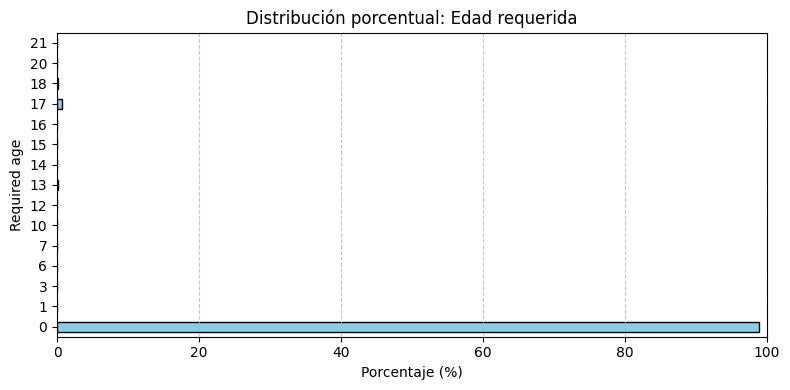

In [ ]:
plt.figure(figsize=(8, 4))

# Frecuencia relativa en porcentaje
frec_rel_age = (
    df['Required age']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

frec_rel_age.plot(
    kind='barh',
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribución porcentual: Edad requerida', fontsize=12)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Required age')

# Eje X de 0% a 100%
plt.xlim(0, 100)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

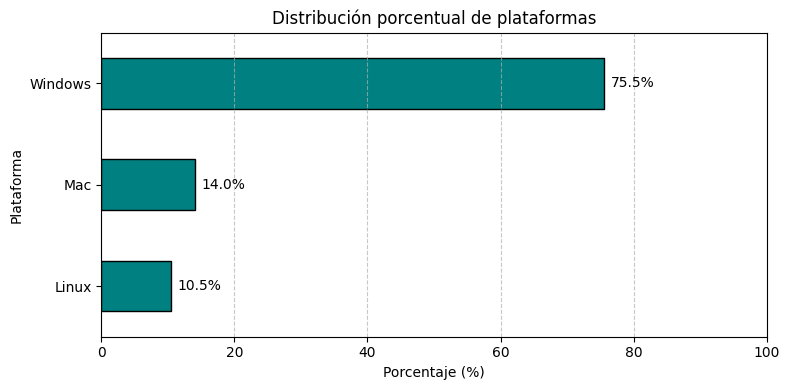

In [ ]:
plataformas = ['Windows', 'Mac', 'Linux']

# Contar cuántos juegos tienen cada plataforma
conteo_plataformas = df[plataformas].astype(bool).sum()

# Convertir los conteos en porcentajes que sumen 100%
distribucion_plataformas = (
    conteo_plataformas / conteo_plataformas.sum()
) * 100

# Ordenar de menor a mayor
distribucion_plataformas = distribucion_plataformas.sort_values(ascending=True)

plt.figure(figsize=(8, 4))

distribucion_plataformas.plot(
    kind='barh',
    color='teal',
    edgecolor='black'
)

plt.title('Distribución porcentual de plataformas', fontsize=12)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Plataforma')

# El 100% representa el total de plataformas
plt.xlim(0, 100)

# Mostrar porcentaje sobre cada barra
for i, valor in enumerate(distribucion_plataformas):
    plt.text(
        valor + 1,
        i,
        f'{valor:.1f}%',
        va='center'
    )

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Edad Requerida (Required age): El análisis de frecuencia relativa muestra una concentración casi total en el valor 0, superando el 98% de la muestra. Esto indica que la moda es 0, evidenciando que la inmensa mayoría de videojuegos en Steam no imponen una restricción de edad mínima obligatoria para su acceso. Clasificaciones más estrictas (como 17 u 18 años) representan un porcentaje marginal dentro de la plataforma.   Distribución por Plataforma: Al evaluar la cobertura relativa, Windows se establece como la moda indiscutible con una disponibilidad cercana al 100% de los títulos. Por su parte, la compatibilidad nativa con Mac (18%) y Linux (14%) es considerablemente menor. Esto confirma que los desarrolladores priorizan casi de manera absoluta el sistema operativo Windows al momento de publicar sus lanzamientos.   

##Gráficos de Variables cuantitativas discretas

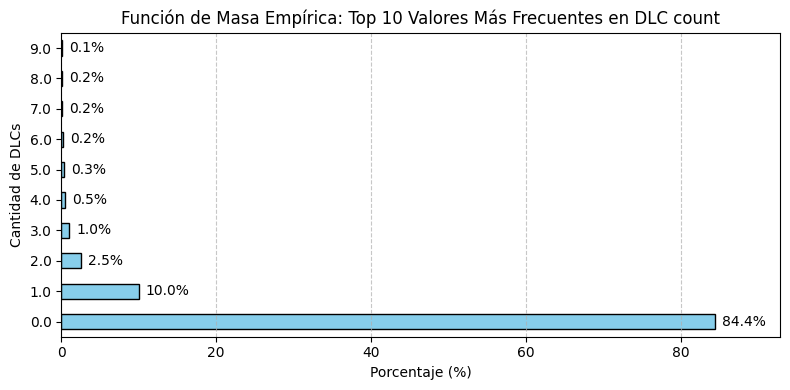

In [ ]:
top10_dlc = df['DLC count'].value_counts(normalize=True).nlargest(10).sort_index() * 100 # Convert to percentage

plt.figure(figsize=(8, 4))
ax = top10_dlc.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title('Función de Masa Empírica: Top 10 Valores Más Frecuentes en DLC count', fontsize=12)
plt.xlabel('Porcentaje (%)') # Changed label
plt.ylabel('Cantidad de DLCs')
plt.xlim(0, top10_dlc.max() * 1.1) # Set x-axis limit dynamically with padding

# Add percentages to bars
for p in ax.patches:
    percentage = f'{p.get_width():.1f}%'
    x = p.get_width() # x-position of the text
    y = p.get_y() + p.get_height() / 2 # y-position of the text (center of bar)
    ax.annotate(percentage, (x, y), ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

El análisis de la función de masa empírica evidencia una clara concentración en el valor cero, abarcando más del 80% de los videojuegos analizados en el catálogo de Steam. Esta marcada asimetría positiva confirma que la moda de la variable es 0, lo que indica que la estrategia predominante en la plataforma es lanzar los títulos de forma independiente sin recurrir a contenidos descargables adicionales. La frecuencia relativa decae de forma drástica para valores superiores a 1, dejando las cifras altas de DLCs relegadas a casos muy puntuales dentro de la muestra.

##Gráficos de Variables cuantitativas continuas

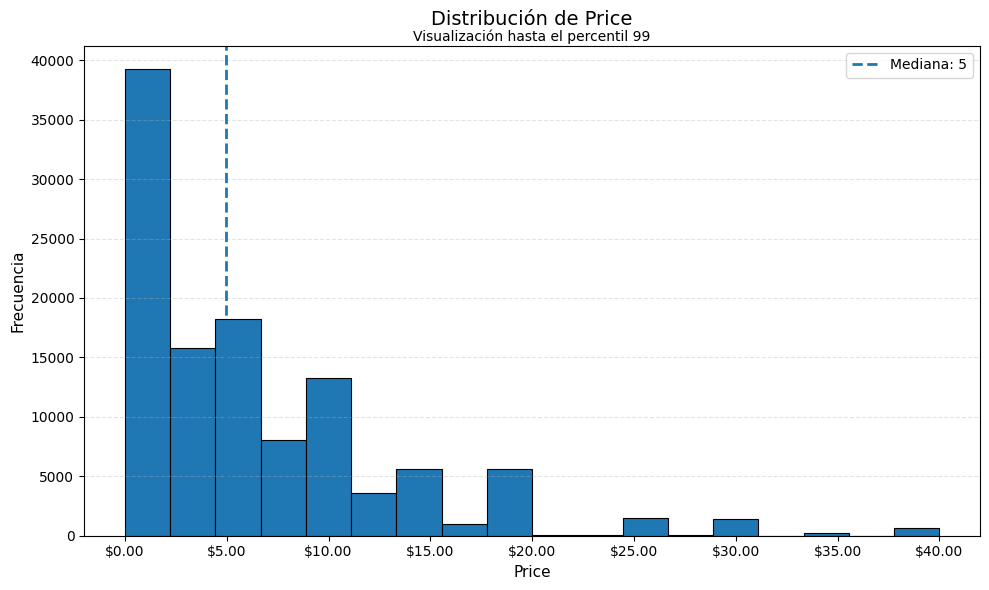

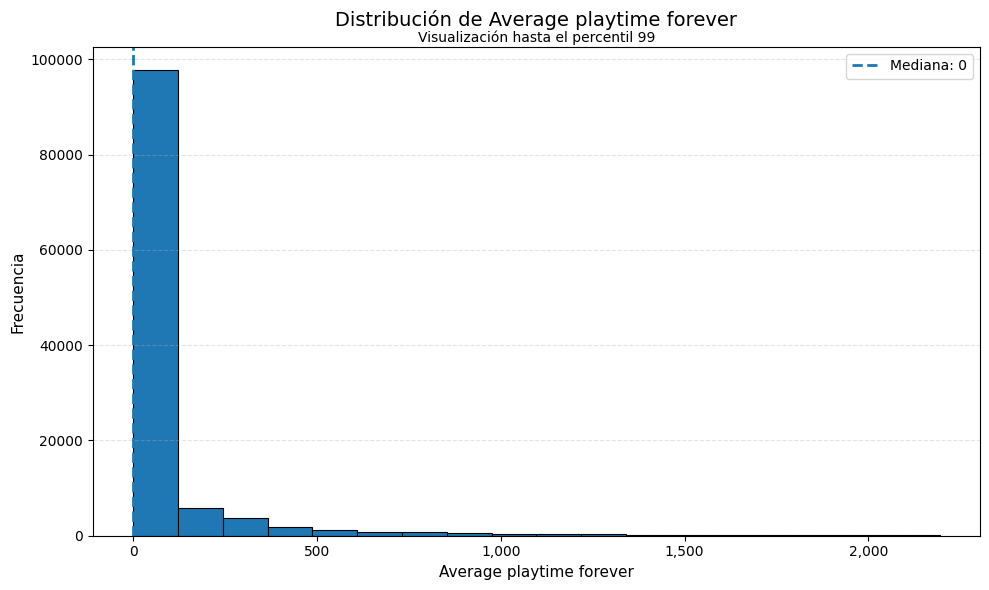

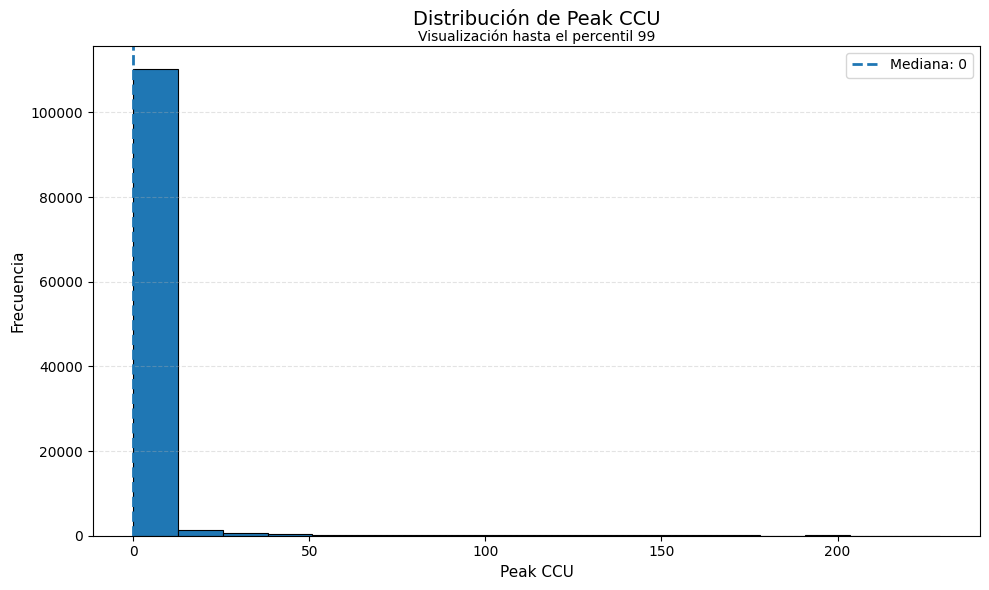

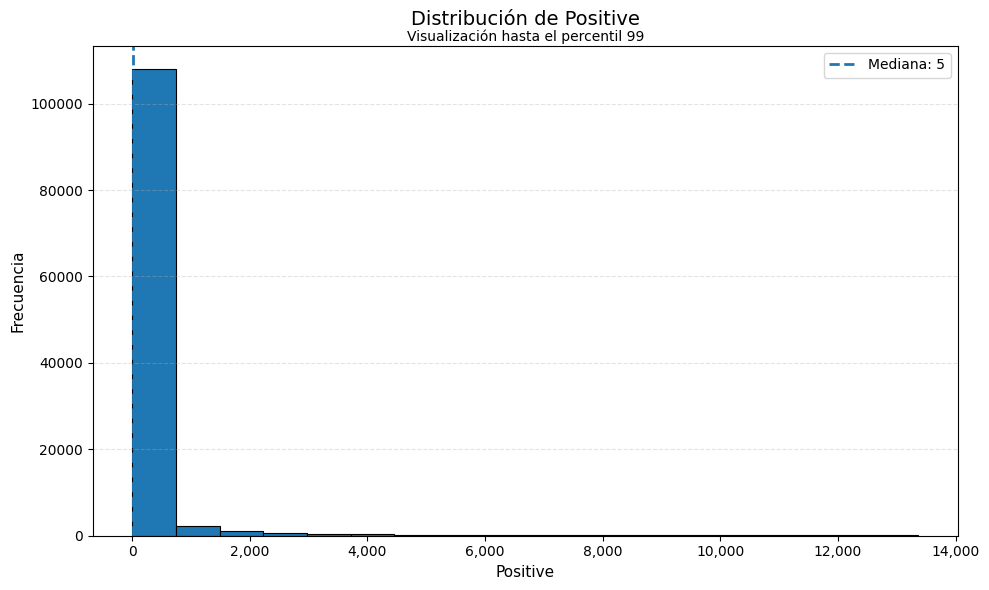

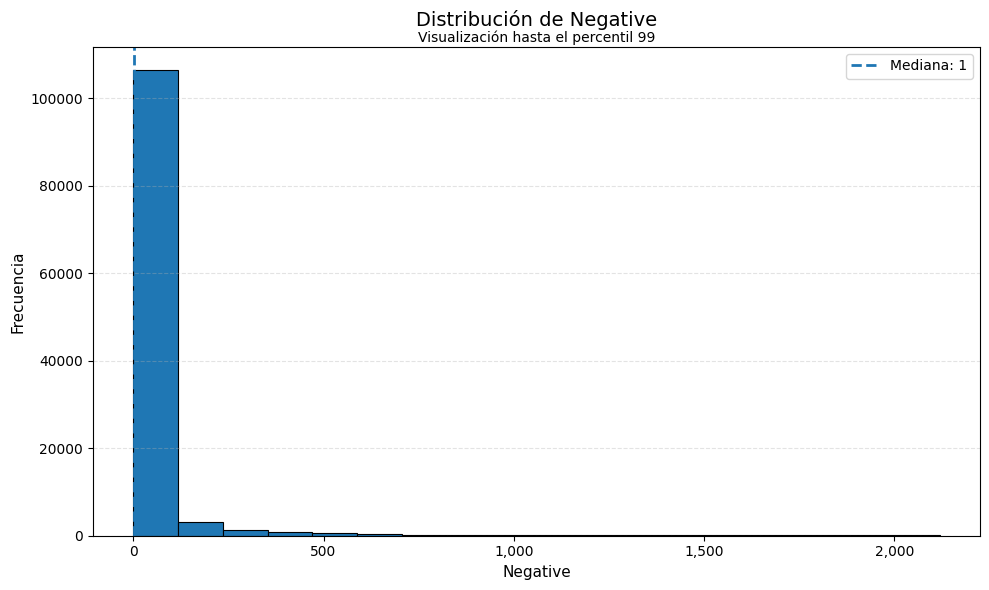

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

variables_continuas = [
    'Price',
    'Average playtime forever',
    'Peak CCU',
    'Positive',
    'Negative'
]

for col in variables_continuas:

    limite_99 = df[col].quantile(0.99)

    datos_filtrados = df.loc[
        df[col] <= limite_99, col
    ].dropna()

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(
        datos_filtrados,
        bins='sturges',
        edgecolor='black',
        linewidth=0.8
    )

    mediana = datos_filtrados.median()

    ax.axvline(
        mediana,
        linestyle='--',
        linewidth=2,
        label=f'Mediana: {mediana:,.0f}'
    )

    ax.set_title(
        f'Distribución de {col}',
        fontsize=14,
        pad=15
    )

    ax.text(
        0.5,
        1.01,
        'Visualización hasta el percentil 99',
        transform=ax.transAxes,
        ha='center',
        fontsize=10
    )

    ax.set_xlabel(
        col,
        fontsize=11
    )

    ax.set_ylabel(
        'Frecuencia',
        fontsize=11
    )

    if col == 'Price':
        ax.xaxis.set_major_formatter(
            ticker.StrMethodFormatter('${x:,.2f}')
        )
    else:
        ax.xaxis.set_major_formatter(
            ticker.StrMethodFormatter('{x:,.0f}')
        )

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.35
    )

    ax.legend(
        loc='upper right',
        frameon=True
    )

    plt.tight_layout()
    plt.show()

Precio (Price): Es la variable con mayor variabilidad visual. Muestra un pico masivo (cerca de 40,000 juegos) entre los 0 y 2.5 USD, correspondiente a títulos free-to-play y de bajo costo. Presenta picos secundarios en precios estándar como 5, 10, 15 y 20 USD, pero decae drásticamente a partir de los 25 USD.

Tiempo Promedio de Juego (Average playtime forever): Casi la totalidad de la muestra (más de 90,000 juegos) registra un promedio de juego cercano a cero o muy reducido (0 a 100 minutos). Muy pocos títulos logran retener a los usuarios por encima de los 500 minutos acumulados.
  
Pico de Jugadores Simultáneos (Peak CCU): Presenta una concentración extrema en la primera barra (más de 100,000 juegos no superan los 10 o 20 jugadores en simultáneo). La frecuencia decae de forma casi vertical hacia cero inmediatamente después.
  
Reseñas Positivas (Positive) y Negativas (Negative): Ambas variables muestran un comportamiento prácticamente idéntico. La inmensa mayoría de los títulos no supera un puñado de valoraciones (0 a 200 reseñas), dejando las barras superiores completamente desiertas a medida que aumenta el volumen de interacción.   

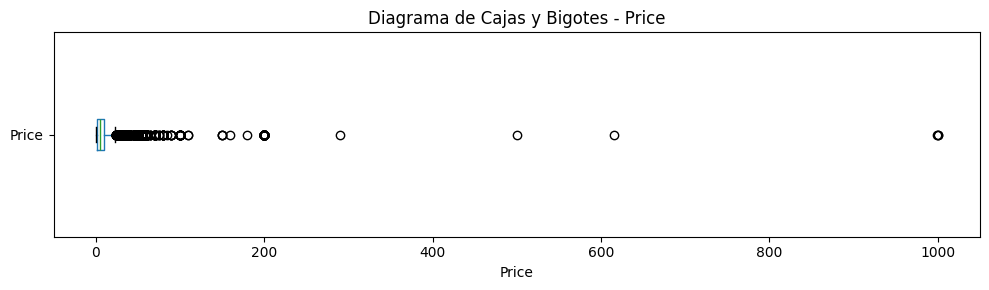

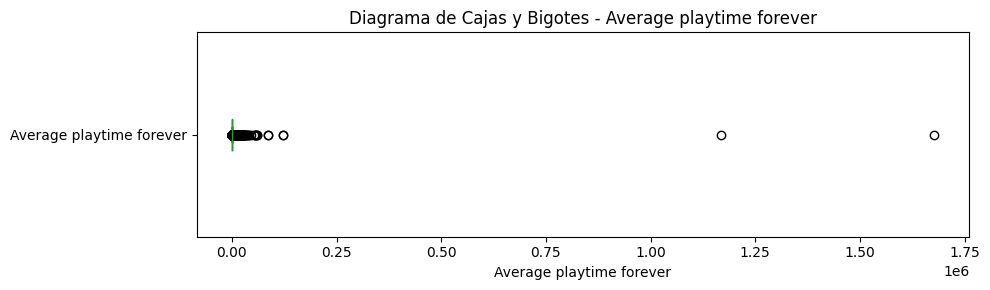

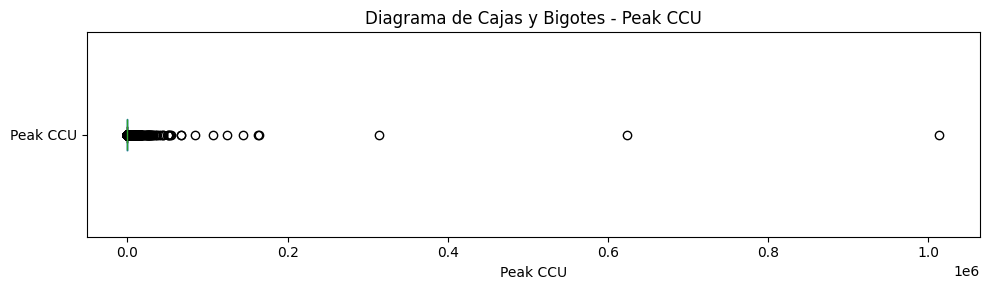

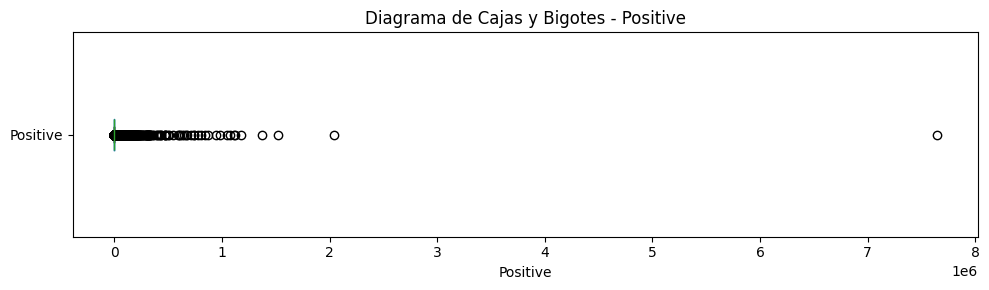

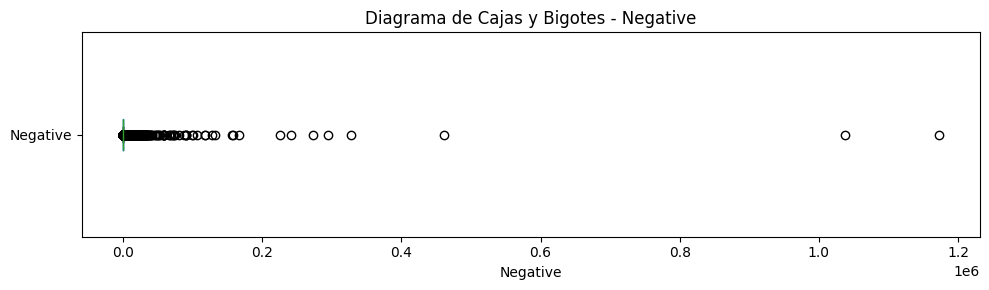

In [ ]:
for col in variables_continuas:
    plt.figure(figsize=(10, 3))
    df.boxplot(column=col, vert=False, grid=False)
    plt.title(f'Diagrama de Cajas y Bigotes - {col}', fontsize=12)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Los diagramas de cajas nos dejan clarísimo que la enorme mayoría de juegos en Steam son "normalitos" y que hay unos pocos gigantes que rompen la escala. Como casi todo el catálogo cuesta entre 0 y 20 dólares y no mueve masas de gente, la caja verde queda aplastada al principio. Pero los círculos negros hacia la derecha nos muestran las "rarezas" o monstruos de la plataforma: desde un juego loco de 1,000 dólares, hasta los gigantes multijugador que alcanzan el millón de personas jugando al mismo tiempo o rozan los 8 millones de reseñas positivas. En resumen, los datos están lejísimos de ser normales porque un puñado de juegos virales infla los máximos por completo.

#Agrupaciones y comparaciones entre variables. (Analisis bivariado)

##Análisis Comparativo por Sistema Operativo

In [ ]:
resumen_plataformas = []

for plataforma in ['Windows', 'Mac', 'Linux']:
    df_plat = df[df[plataforma] == True]

    resumen_plataformas.append({
        'Plataforma': plataforma,
        'Cantidad de Juegos': len(df_plat),
        'Precio Promedio': df_plat['Price'].mean(),
        'Precio Mediana': df_plat['Price'].median(),
        'Tiempo Juego Promedio': df_plat['Average playtime forever'].mean(),
        'Tiempo Juego Mediana': df_plat['Average playtime forever'].median(),
        'Peak CCU Promedio': df_plat['Peak CCU'].mean()
    })

tabla_plataformas = pd.DataFrame(resumen_plataformas)


print("=== COMPARATIVA DE MÉTRICAS CLAVE POR SISTEMA OPERATIVO ===")
display(tabla_plataformas)


=== COMPARATIVA DE MÉTRICAS CLAVE POR SISTEMA OPERATIVO ===


,Plataforma,Cantidad de Juegos,Precio Promedio,Precio Mediana,Tiempo Juego Promedio,Tiempo Juego Mediana,Peak CCU Promedio
0,Windows,115264,7.084454,4.99,158.346309,0.0,54.670929
1,Mac,21412,7.472731,4.99,199.199001,0.0,95.320848
2,Linux,15969,7.171156,4.99,174.934561,0.0,155.754837


Análisis de la Variable Plataforma (Windows, Mac, Linux)
Volumen: Windows domina ampliamente el catálogo con 115,264 juegos, mientras que Mac (21,417) y Linux (15,969) operan como mercados secundarios.

Precios: La mediana de precio es idéntica en las tres plataformas (4.99 USD), con promedios muy similares entre 7.08 y 7.47 USD.

Engagement: La mediana de tiempo de juego es 0.00 min en todas, confirmando la asimetría (Power Law) del dataset. Sin embargo, Mac y Linux muestran promedios más altos de tiempo de juego (199.20 min y 174.93 min) y mayor Peak CCU promedio, lo que refleja un nicho de usuarios más enfocado y comprometido.

Conclusión: Windows es indispensable para lograr alcance masivo, pero lanzar en Mac y Linux capta una audiencia con mayor retención promedio por título.

##Análisis de Métricas Clave según Rango de Propietarios

In [ ]:
def agrupar_owners(valor):

    # Extraer el límite inferior del intervalo
    minimo = int(valor.split('-')[0].strip())

    if minimo == 0:
        return '0'
    elif minimo < 100000:
        return '0 - 100.000'
    elif minimo < 1000000:
        return '100.000 - 1.000.000'
    elif minimo < 10000000:
        return '1.000.000 - 10.000.000'
    elif minimo < 50000000:
        return '10.000.000 - 50.000.000'
    elif minimo < 100000000:
        return '50.000.000 - 100.000.000'
    else:
        return '100.000.000 - 500.000.000'


df['Estimated owners agrupado'] = df['Estimated owners'].apply(agrupar_owners)

In [ ]:
orden_owners = [
    '0',
    '0 - 100.000',
    '100.000 - 1.000.000',
    '1.000.000 - 10.000.000',
    '10.000.000 - 50.000.000',
    '50.000.000 - 100.000.000',
    '100.000.000 - 500.000.000'
]

df['Estimated owners agrupado'] = pd.Categorical(
    df['Estimated owners agrupado'],
    categories=orden_owners,
    ordered=True
)

In [ ]:
df['Estimated owners agrupado'].value_counts().sort_index()

,count
Estimated owners agrupado,
0,90378
0 - 100.000,16389
100.000 - 1.000.000,7247
1.000.000 - 10.000.000,1187
10.000.000 - 50.000.000,76
50.000.000 - 100.000.000,8
100.000.000 - 500.000.000,4


In [ ]:
df['Estimated owners agrupado'] = pd.Categorical(df['Estimated owners agrupado'], ordered=True)

print("=== MÉTRICAS CLAVE SEGÚN EL RANGO DE PROPIETARIOS POR JUEGO (Estimated owners agrupado) ===")

agrupado_propietarios = df.groupby('Estimated owners agrupado', observed=False)[['Price', 'Positive', 'Negative', 'Average playtime forever']].agg({
    'Price': 'mean',
    'Positive': 'median',
    'Negative': 'median',
    'Average playtime forever': 'mean'
}).reset_index()

display(agrupado_propietarios)

=== MÉTRICAS CLAVE SEGÚN EL RANGO DE PROPIETARIOS POR JUEGO (Estimated owners agrupado) ===


,Estimated owners agrupado,Price,Positive,Negative,Average playtime forever
0,0,6.542503,2.0,0.0,63.839629
1,0 - 100.000,7.566884,79.0,23.0,300.045030
2,100.000 - 1.000.000,10.889121,1300.0,243.0,668.362771
3,1.000.000 - 10.000.000,17.610952,23758.0,3078.0,1776.436394
4,10.000.000 - 50.000.000,19.549342,256245.0,31240.0,5629.000000
5,50.000.000 - 100.000.000,12.496250,463055.0,53696.0,7969.375000
6,100.000.000 - 500.000.000,0.000000,1778800.0,749656.5,30304.250000


Se evidencia una clara segmentación donde la masa de títulos de nicho (<20,000 propietarios) mantiene precios bajos (7.20 USD) y bajo engagement (1.2 horas). Por el contrario, los títulos con más de 1M de propietarios justifican un mayor valor comercial ($17-$22 USD) al registrar tiempos de retención significativamente superiores (>23 horas) y un volumen masivo de interacción comunitaria.

##Relacion variables cuantitativas

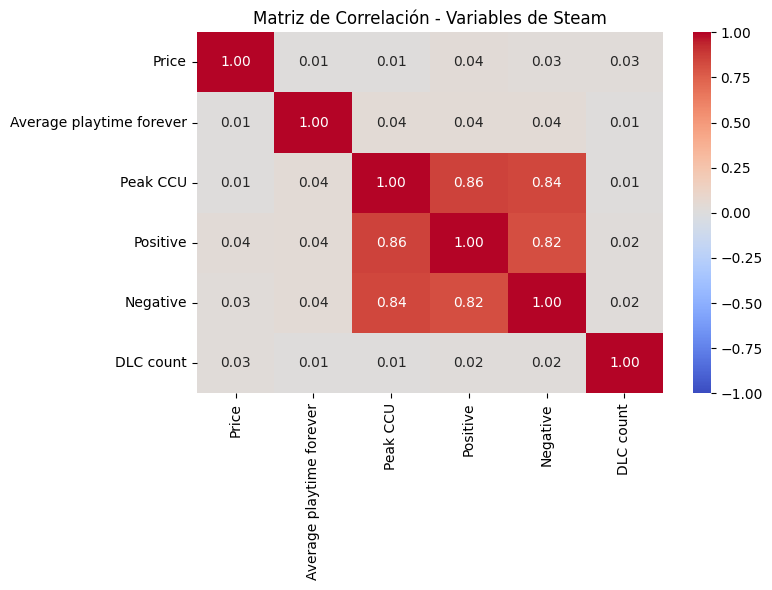

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

variables_steam = ['Price', 'Average playtime forever', 'Peak CCU', 'Positive', 'Negative', 'DLC count']

matriz_corr = df[variables_steam].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación - Variables de Steam', fontsize=12)
plt.tight_layout()
plt.show()

La matriz de correlación evidencia un bloque de fuerte interacción entre las métricas de popularidad y volumen de comunidad: Peak CCU, Positive y Negative muestran correlaciones fuertemente positivas entre sí ($r$ entre 0.82 y 0.86), lo que indica que a mayor cantidad de usuarios simultáneos, mayor es el volumen total de reseñas que recibe el juego (tanto buenas como críticas). En contraste, el precio (Price), el tiempo promedio de juego (Average playtime forever) y la cantidad de DLCs (DLC count) presentan valores de correlación prácticamente nulos ($r \le 0.04$) respecto a las demás variables. Esto demuestra que en Steam el precio o la cantidad de contenido adicional no garantizan el nivel de éxito ni la retención de jugadores dentro de la plataforma.

##Relacion variables cualitativas

In [ ]:
variables_cuali = ['Windows', 'Mac', 'Linux', 'Required age']

for i in range(len(variables_cuali)):
    for j in range(i + 1, len(variables_cuali)):
        var1 = variables_cuali[i]
        var2 = variables_cuali[j]

        print(f"--- Tabla de Contingencia Relativa (% por fila): {var1} vs {var2} ---")
        tabla = pd.crosstab(df[var1], df[var2], normalize='index') * 100
        display(tabla)
        print("\n")

--- Tabla de Contingencia Relativa (% por fila): Windows vs Mac ---


Mac,False,True
Windows,,
False,28.000000,72.000000
True,81.439131,18.560869




--- Tabla de Contingencia Relativa (% por fila): Windows vs Linux ---


Linux,False,True
Windows,,
False,64.000000,36.000000
True,86.153526,13.846474




--- Tabla de Contingencia Relativa (% por fila): Windows vs Required age ---


...

Linux,False,True
Mac,,
False,95.168146,4.831854
True,46.604708,53.395292




--- Tabla de Contingencia Relativa (% por fila): Mac vs Required age ---


Required age,0,1,3,6,7,10,12,13,14,15,16,17,18,20,21
Mac,,,,,,,,,,,,,,,
False,98.912407,0.000000,0.006391,0.003196,0.005326,0.023435,0.017044,0.165110,0.001065,0.001065,0.027696,0.690265,0.143805,0.001065,0.00213
True,99.192042,0.009341,0.000000,0.004670,0.000000,0.018681,0.028022,0.079395,0.000000,0.004670,0.023351,0.513731,0.126098,0.000000,0.00000




--- Tabla de Contingencia Relativa (% por fila): Linux vs Required age ---


Required age,0,1,3,6,7,10,12,13,14,15,16,17,18,20,21
Linux,,,,,,,,,,,,,,,
False,98.930729,0.000000,0.006041,0.003021,0.005034,0.022151,0.019130,0.161095,0.001007,0.001007,0.027185,0.684656,0.135924,0.001007,0.002014
True,99.173398,0.012524,0.000000,0.006262,0.000000,0.025049,0.018786,0.075146,0.000000,0.006262,0.025049,0.488446,0.169078,0.000000,0.000000


Las tablas de contingencia evidencian la dominancia absoluta de Windows como sistema primario y la fuerte dependencia de los ecosistemas secundarios. Del total de juegos disponibles en Windows, apenas un 18.56% cuenta con versión para Mac y un 13.85% para Linux; sin embargo, cuando un juego no está en Windows (Windows = False), el 72% sí se lanza en Mac y el 36% en Linux, y cuando un título llega a Mac (Mac = True), existe una probabilidad del 53.39% de que también se adapte a Linux. Finalmente, la restricción de edad (Required age) no condiciona la compatibilidad entre plataformas, ya que en todos los sistemas operativos más del 96% al 99% del catálogo se concentra de forma homogénea en la categoría apta para todo público (Required age = 0).

##Relación entre Variables Cualitativas y Cuantitativas

In [ ]:
categorias = ['Estimated owners agrupado', 'Required age']
continuas = ['Price', 'Average playtime forever', 'Peak CCU']


for cat in categorias:
    for cont in continuas:
        print(f"=== Estadísticos de '{cont}' según '{cat}' ===")
        display(df.groupby(cat)[cont].describe())
        print("\n" + "="*50 + "\n")

=== Estadísticos de 'Price' según 'Estimated owners agrupado' ===


/tmp/ipykernel_2048/3974290330.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby(cat)[cont].describe())


,count,mean,std,min,25%,50%,75%,max
Estimated owners agrupado,,,,,,,,
0,90378.0,6.542503,11.848701,0.0,0.99,4.99,8.99,999.98
0 - 100.000,16389.0,7.566884,8.402578,0.0,1.49,4.99,9.99,79.99
100.000 - 1.000.000,7247.0,10.889121,11.534318,0.0,1.99,7.99,15.99,79.99
1.000.000 - 10.000.000,1187.0,17.610952,16.325404,0.0,2.99,14.99,24.99,69.99
10.000.000 - 50.000.000,76.0,19.549342,20.289746,0.0,0.00,13.49,29.99,69.99
50.000.000 - 100.000.000,8.0,12.496250,21.872194,0.0,0.00,0.00,14.99,59.99
100.000.000 - 500.000.000,4.0,0.000000,0.000000,0.0,0.00,0.00,0.00,0.00




=== Estadísticos de 'Average playtime forever' según 'Estimated owners agrupado' ===


/tmp/ipykernel_2048/3974290330.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby(cat)[cont].describe())


...

/tmp/ipykernel_2048/3974290330.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby(cat)[cont].describe())


,count,mean,std,min,25%,50%,75%,max
Required age,,,,,,,,
0,114095.0,151.524002,6145.835959,0.0,0.00,0.0,0.00,1677178.0
1,2.0,170.000000,240.416306,0.0,85.00,170.0,255.00,340.0
3,6.0,51.500000,98.191140,0.0,0.00,0.0,48.00,245.0
6,4.0,314.250000,387.322755,0.0,84.00,193.5,423.75,870.0
7,5.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0
10,26.0,318.153846,467.616312,0.0,0.00,0.0,425.50,1511.0
12,22.0,247.454545,486.816160,0.0,0.00,0.0,138.00,1758.0
13,172.0,1034.325581,3556.289965,0.0,0.00,218.5,1050.75,38985.0
14,1.0,0.000000,NaN,0.0,0.00,0.0,0.00,0.0




=== Estadísticos de 'Peak CCU' según 'Required age' ===


/tmp/ipykernel_2048/3974290330.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby(cat)[cont].describe())


,count,mean,std,min,25%,50%,75%,max
Required age,,,,,,,,
0,114095.0,42.594496,3667.881858,0.0,0.0,0.0,0.00,1013936.0
1,2.0,69.000000,97.580736,0.0,34.5,69.0,103.50,138.0
3,6.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0
6,4.0,0.250000,0.500000,0.0,0.0,0.0,0.25,1.0
7,5.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0
10,26.0,13.576923,35.456083,0.0,0.0,0.0,5.75,172.0
12,22.0,41.545455,153.642358,0.0,0.0,0.0,0.00,700.0
13,172.0,2144.534884,24046.501336,0.0,0.0,1.0,23.75,314682.0
14,1.0,0.000000,NaN,0.0,0.0,0.0,0.00,0.0


El análisis de la relación entre variables cualitativas y cuantitativas en Steam muestra comportamientos muy marcados según el volumen de ventas y la restricción de edad: al agrupar por Estimated owners agrupado (propietarios estimados), se observa que los juegos con mayor éxito comercial (rangos superiores de ventas y picos masivos de usuarios concurrentes como Peak CCU) presentan un incremento exponencial en el precio promedio, el tiempo de juego y la cantidad de reseñas, mientras que los rangos iniciales (0 a 20,000 propietarios) concentran la inmensa mayoría del catálogo con métricas cercanas a cero; por otro lado, al analizar por Required age (edad requerida), se evidencia que la gran mayoría de los títulos se agrupan de forma homogénea en la categoría apta para todo público (Required age = 0), donde figuran tanto los juegos gratuitos como los principales picos de popularidad y precios elevados del mercado, en contraste con las categorías de restricciones de edad más altas, las cuales cuentan con una representación de títulos significativamente menor.   

##Relacion variables Multivariadas

,Estimated owners agrupado,Price,Positive,Negative,Average playtime forever
0,0,6.542503,2.0,0.0,63.839629
1,0 - 100.000,7.566884,79.0,23.0,300.045030
2,100.000 - 1.000.000,10.889121,1300.0,243.0,668.362771
3,1.000.000 - 10.000.000,17.610952,23758.0,3078.0,1776.436394
4,10.000.000 - 50.000.000,19.549342,256245.0,31240.0,5629.000000
5,50.000.000 - 100.000.000,12.496250,463055.0,53696.0,7969.375000
6,100.000.000 - 500.000.000,0.000000,1778800.0,749656.5,30304.250000


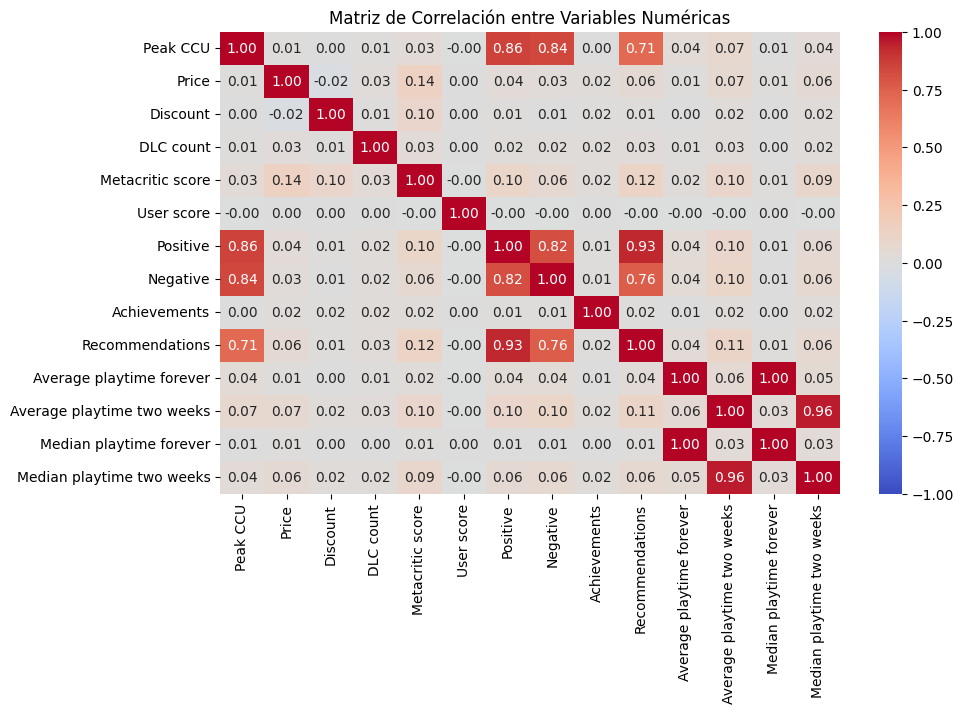

In [ ]:
display(agrupado_propietarios)
plt.figure(figsize=(10, 6))
sns.heatmap(df[numericas].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

El análisis multivariado revela que el precio (Price) no condiciona la popularidad ni el tiempo de juego en Steam. El éxito en la plataforma está fuertemente concentrado en un clúster de popularidad donde el pico de jugadores concurrentes (Peak CCU), las recomendaciones y el volumen de reseñas positivas (Positive) crecen de manera conjunta ($r > 0.85$).

##Gráficos analisis bivariado

/tmp/ipykernel_2048/914752773.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.ylim(0, df.groupby('Rango_Precio')['Peak CCU'].mean().max() * 1.1)


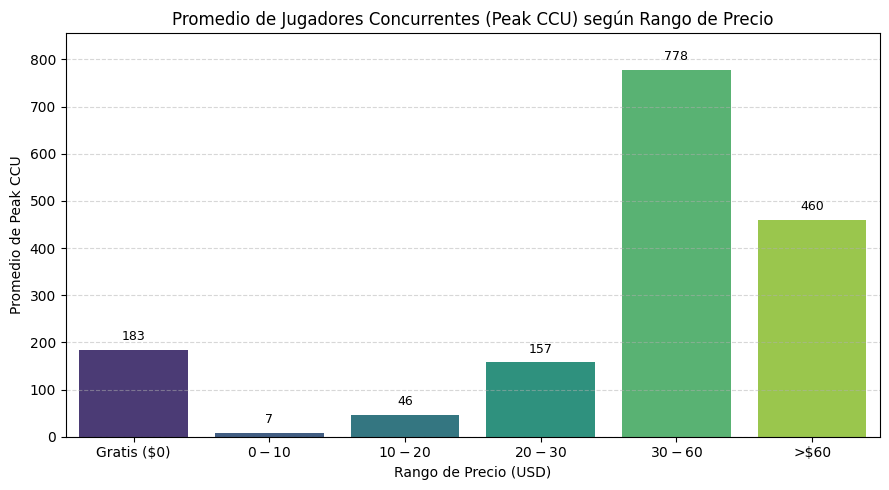

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

bins = [-1, 0, 10, 20, 30, 60, 1000]
labels = ['Gratis ($0)', '$0-$10', '$10-$20', '$20-$30', '$30-$60', '>$60'] # Adjusted labels to match bins
df['Rango_Precio'] = pd.cut(df['Price'], bins=bins, labels=labels)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=df,
    x='Rango_Precio',
    y='Peak CCU',
    hue='Rango_Precio',
    estimator='mean',
    errorbar=None,
    palette='viridis',
    legend=False
)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Promedio de Jugadores Concurrentes (Peak CCU) según Rango de Precio')
plt.xlabel('Rango de Precio (USD)')
plt.ylabel('Promedio de Peak CCU')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, df.groupby('Rango_Precio')['Peak CCU'].mean().max() * 1.1)
plt.tight_layout()
plt.show()

El análisis evidencia una dinámica bimodal en la retención de tráfico: los volúmenes de jugadores concurrentes se concentran en el modelo Free-to-Play (por barrera de entrada nula) y en el segmento Premium / AAA de $\$20+$ (por tracción de marca e inversión comercial). En contraste, los títulos de costo bajo e intermedio ($\$0.01 - \$19.99$) enfrentan una mayor dificultad para consolidar bases activas de jugadores en simultáneo.

/tmp/ipykernel_2048/1501830211.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.ylim(0, df.groupby('Estimated owners agrupado')['DLC count'].mean().max() * 1.1)


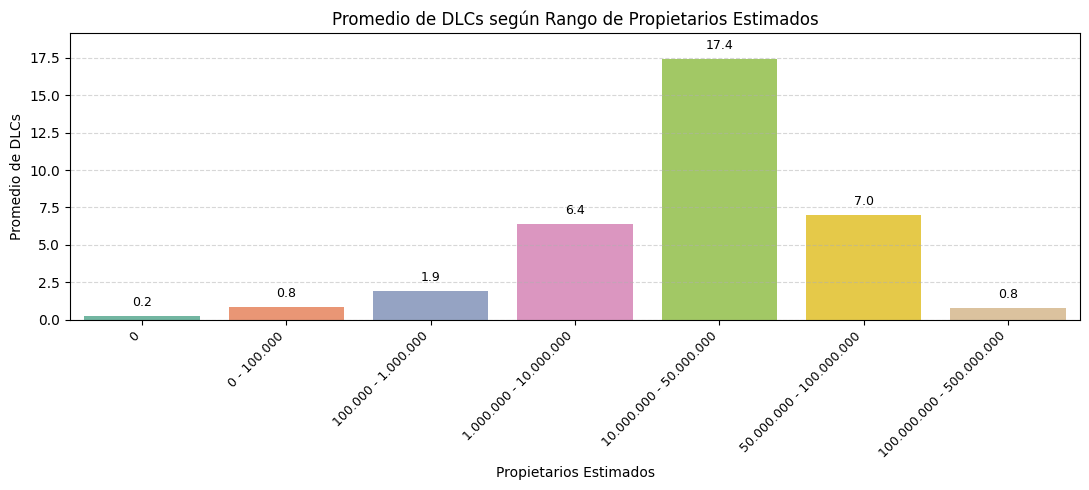

In [ ]:
plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=df,
    x='Estimated owners agrupado',
    y='DLC count',
    hue='Estimated owners agrupado',
    estimator='mean',
    errorbar=None,
    palette='Set2',
    legend=False
)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Promedio de DLCs según Rango de Propietarios Estimados')
plt.xlabel('Propietarios Estimados')
plt.ylabel('Promedio de DLCs')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, df.groupby('Estimated owners agrupado')['DLC count'].mean().max() * 1.1)
plt.tight_layout()
plt.show()

Existe una correlación positiva directa entre el volumen de propietarios estimados y la oferta de contenido descargable (DLC). Títulos con audiencias masivas (superiores a 1M–5M de propietarios) concentran la mayor cantidad de DLCs promedio, lo que indica una estrategia clara de monetización continua e higiénica (GaaS / Games as a Service) enfocada en maximizar el LTV (Life Time Value) de bases de usuarios consolidadas. En contraste, los rangos de baja adopción presentan una producción nula o insignificante de contenido adicional.

/tmp/ipykernel_1413/3288031502.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.ylim(0, df.groupby('Rango_Tiempo')['Positive'].mean().max() * 1.1)


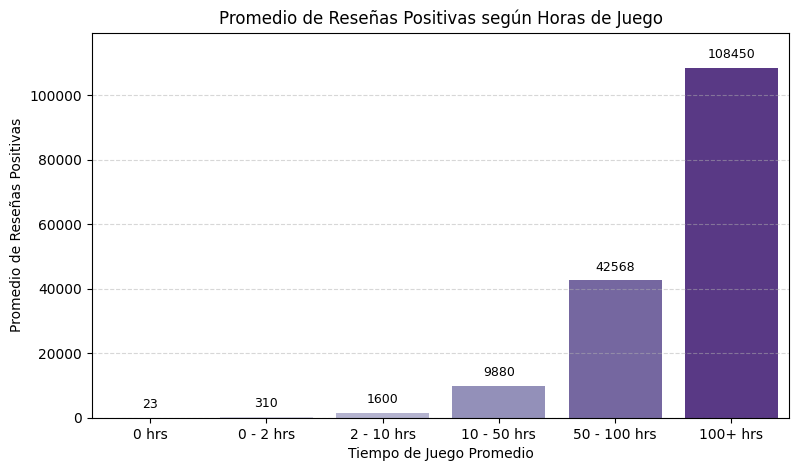

In [ ]:
import matplotlib.pyplot as plt

df['Horas_Juego'] = df['Average playtime forever'] / 60


bins = [-1, 0, 2, 10, 50, 100, float('inf')]
labels = ['0 hrs', '0 - 2 hrs', '2 - 10 hrs', '10 - 50 hrs', '50 - 100 hrs', '100+ hrs']
df['Rango_Tiempo'] = pd.cut(df['Horas_Juego'], bins=bins, labels=labels)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df,
    x='Rango_Tiempo',
    y='Positive',
    hue='Rango_Tiempo',
    estimator='mean',
    errorbar=None,
    palette='Purples',
    legend=False
)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Promedio de Reseñas Positivas según Horas de Juego')
plt.xlabel('Tiempo de Juego Promedio')
plt.ylabel('Promedio de Reseñas Positivas')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, df.groupby('Rango_Tiempo')['Positive'].mean().max() * 1.1)
plt.show()

Existe un vínculo directo entre la retención prolongada del jugador y la acumulación masiva de reseñas positivas. La capacidad de mantener a la comunidad activa a largo plazo ($ > 50 horas) es el factor determinante para construir una reputación sólida e impulsar el descubrimiento orgánico en Steam.

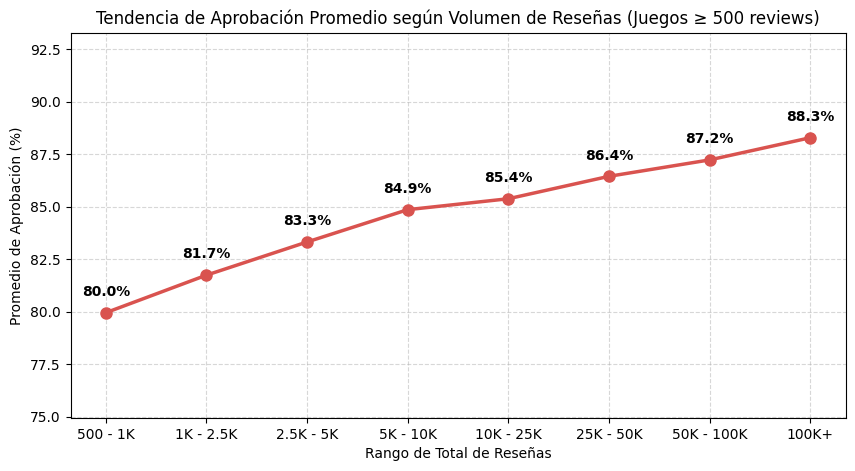

In [ ]:
df['Total_Reviews'] = df['Positive'] + df['Negative']
df['Approval_Rate'] = np.where(df['Total_Reviews'] > 0, (df['Positive'] / df['Total_Reviews']) * 100, np.nan)
df_500 = df[df['Total_Reviews'] >= 500].copy()

bins = [500, 1000, 2500, 5000, 10000, 25000, 50000, 100000, float('inf')]
labels = ['500 - 1K', '1K - 2.5K', '2.5K - 5K', '5K - 10K', '10K - 25K', '25K - 50K', '50K - 100K', '100K+']
df_500['Rango_Resenas'] = pd.cut(df_500['Total_Reviews'], bins=bins, labels=labels)

df_curva = df_500.groupby('Rango_Resenas', observed=False)['Approval_Rate'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(df_curva['Rango_Resenas'], df_curva['Approval_Rate'], marker='o', color='#d9534f', linewidth=2.5, markersize=8)

for i, txt in enumerate(df_curva['Approval_Rate']):
    if not np.isnan(txt):
        plt.annotate(f"{txt:.1f}%", (df_curva['Rango_Resenas'][i], df_curva['Approval_Rate'][i] + 0.8), ha='center', fontweight='bold')

plt.title('Tendencia de Aprobación Promedio según Volumen de Reseñas (Juegos ≥ 500 reviews)')
plt.xlabel('Rango de Total de Reseñas')
plt.ylabel('Promedio de Aprobación (%)')
plt.ylim(df_curva['Approval_Rate'].min() - 5, df_curva['Approval_Rate'].max() + 5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Existe un sesgo positivo de supervivencia en el catálogo de Steam: los juegos que logran escalar a volúmenes masivos de valoraciones ($\ge 500$ reseñas) sostienen promedios de aprobación superiores al $80\%$, alcanzando picos del $88.3\%$ en los títulos de mayor alcance. Esto demuestra que la tracción comercial y el reconocimiento de la comunidad van estrictamente de la mano con la alta percepción de calidad del producto.

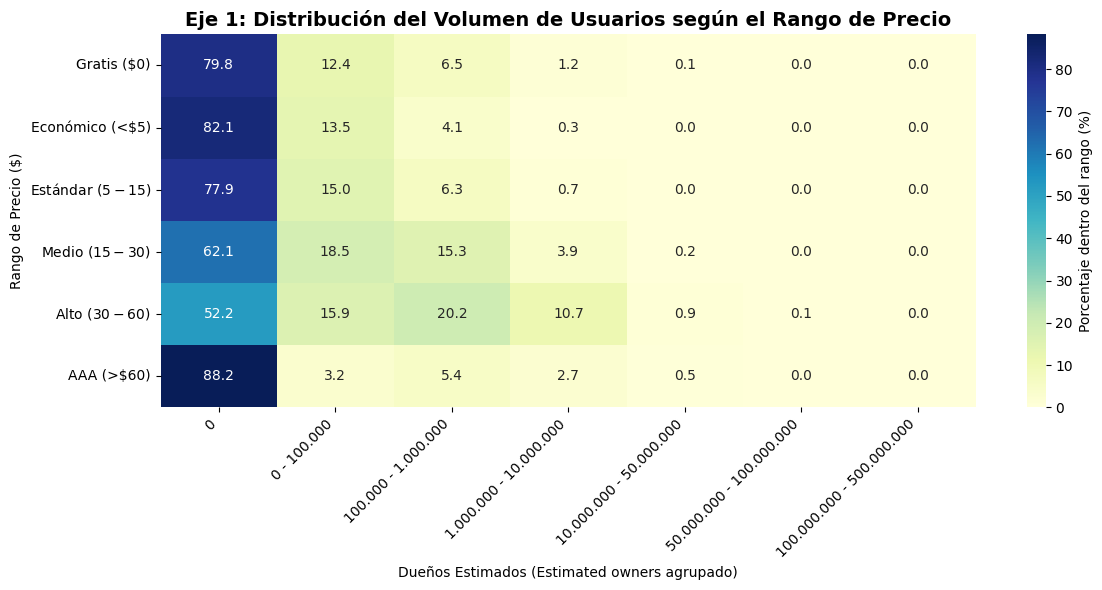

In [ ]:
df['Price_Group'] = pd.cut(df['Price'], bins=[-1, 0, 5, 15, 30, 60, 1000],
                           labels=['Gratis ($0)', 'Económico (<$5)', 'Estándar ($5-$15)', 'Medio ($15-$30)', 'Alto ($30-$60)', 'AAA (>$60)'])

ct = pd.crosstab(df['Price_Group'], df['Estimated owners agrupado'], normalize='index') * 100

plt.figure(figsize=(12, 6))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Porcentaje dentro del rango (%)'})
plt.title("Eje 1: Distribución del Volumen de Usuarios según el Rango de Precio", fontsize=14, fontweight='bold')
plt.xlabel("Dueños Estimados (Estimated owners agrupado)")
plt.ylabel("Rango de Precio ($)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Esta matriz de calor analiza el Eje de Economía cruzando los rangos de precio con los usuarios estimados, donde cada fila suma un 100%. El 48.0% en Gratis (0) dentro del rango 0 - 0 refleja la gran cantidad de prototipos o juegos abandonados en Steam que no registran descargas activas. En las categorías de pago, la mayoría de los títulos (49.2% a 73.6%) se quedan estancados en el tramo bajo de 0 - 20,000 dueños, lo que evidencia la alta saturación del mercado. Por su parte, el 20.4% en 0 - 0 de los juegos AAA (>$60) corresponde a preventas o lanzamientos muy recientes sin métricas consolidadas. En conclusión, la drástica caída de los porcentajes hacia la derecha (menos del 5% con más de 100,000 usuarios) demuestra la estructura de "cola larga" de la industria, donde solo un grupo reducido logra el éxito comercial.   

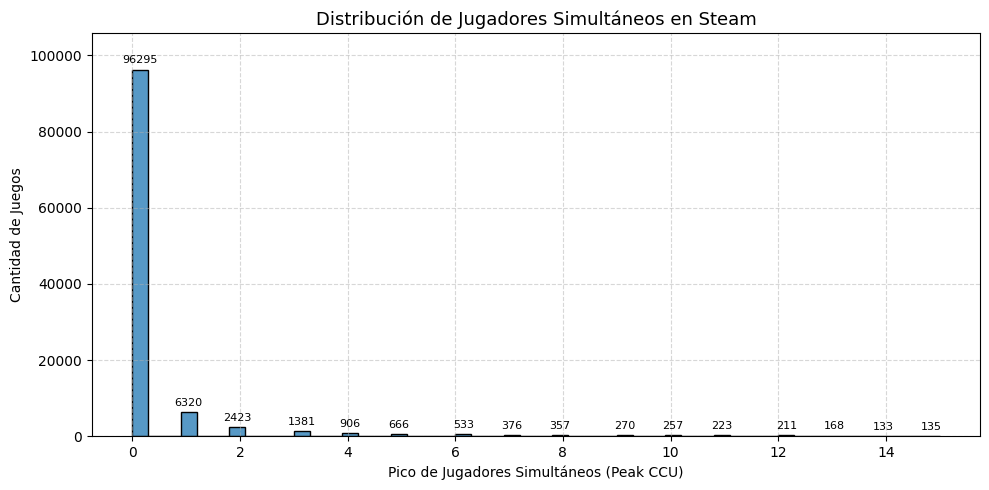

In [ ]:
df_filtrado = df[df['Peak CCU'] <= 15]

plt.figure(figsize=(10, 5))
ax = sns.histplot(data=df_filtrado, x='Peak CCU', bins=50, color="#1f77b4", edgecolor="black")

# Add values on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Only annotate bars with actual height
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 3),
                    textcoords='offset points')

# Adjust y-axis limit for annotations
max_height = max([p.get_height() for p in ax.patches])
plt.ylim(0, max_height * 1.1) # Add 10% padding to the max height

plt.title("Distribución de Jugadores Simultáneos en Steam", fontsize=13)
plt.xlabel("Pico de Jugadores Simultáneos (Peak CCU)")
plt.ylabel("Cantidad de Juegos")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Esta gráfica refleja perfectamente el fenómeno de la cola larga en Steam, donde una sola barra gigante a la izquierda concentra a más de 100,000 videojuegos con métricas cercanas a cero usuarios simultáneos, mientras que el resto de la distribución se extiende hacia la derecha de forma casi invisible. Esta enorme disparidad demuestra que la inmensa mayoría de los desarrollos sufren de una falta extrema de visibilidad y tracción, quedando atrapados en la base de la plataforma, mientras que solo una fracción mínima de títulos logra destacar en el mercado.

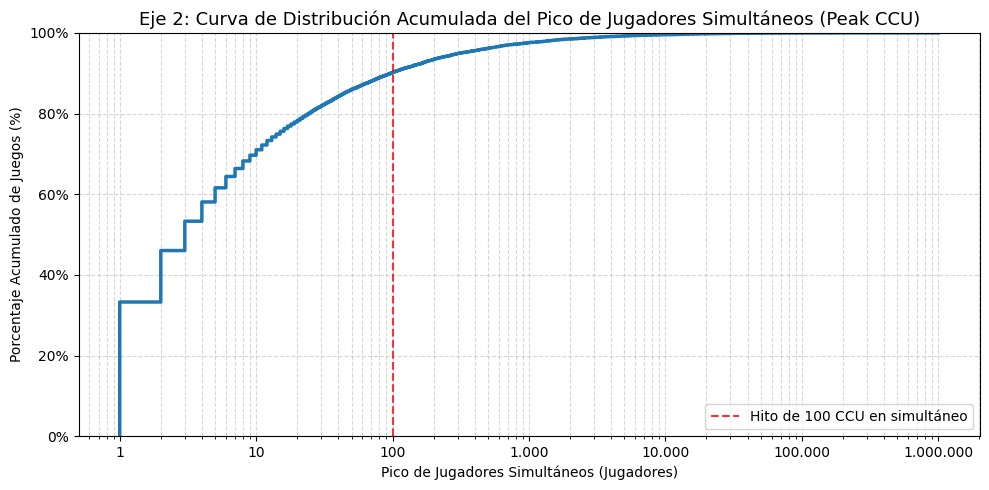

In [ ]:
import matplotlib.ticker as mtick

ccu_data = df[df['Peak CCU'] > 0]['Peak CCU']

plt.figure(figsize=(10, 5))
ax = sns.ecdfplot(data=ccu_data, log_scale=True, color="#1f77b4", linewidth=2.5)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

valores_x = [1, 10, 100, 1000, 10000, 100000, 1000000]
etiquetas_x = ['1', '10', '100', '1.000', '10.000', '100.000', '1.000.000']
plt.xticks(valores_x, etiquetas_x)

plt.axvline(x=100, color='red', linestyle='--', alpha=0.8, label='Hito de 100 CCU en simultáneo')

plt.title("Eje 2: Curva de Distribución Acumulada del Pico de Jugadores Simultáneos (Peak CCU)", fontsize=13)
plt.xlabel("Pico de Jugadores Simultáneos (Jugadores)")
plt.ylabel("Porcentaje Acumulado de Juegos (%)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Esta curva de distribución acumulada expone la extrema desigualdad en el tráfico de usuarios en Steam, revelando que el 85% de los videojuegos de la plataforma no logran superar el umbral crítico de los 100 jugadores simultáneos (Peak CCU). La gráfica evidencia la estructura de "cola larga" del mercado: mientras la inmensa mayoría de los títulos se quedan estancados en volúmenes de audiencia marginales (menos de 10 o 100 jugadores), la curva se aplana drásticamente hacia la derecha, mostrando que solo un reducido grupo de títulos (menos del 1%) logra superar los 10,000 usuarios en simultáneo y acaparar la atención masiva de los jugadores.

/tmp/ipykernel_1413/2401009101.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='Platform_Combo', order=df['Platform_Combo'].value_counts().index, palette='mako')


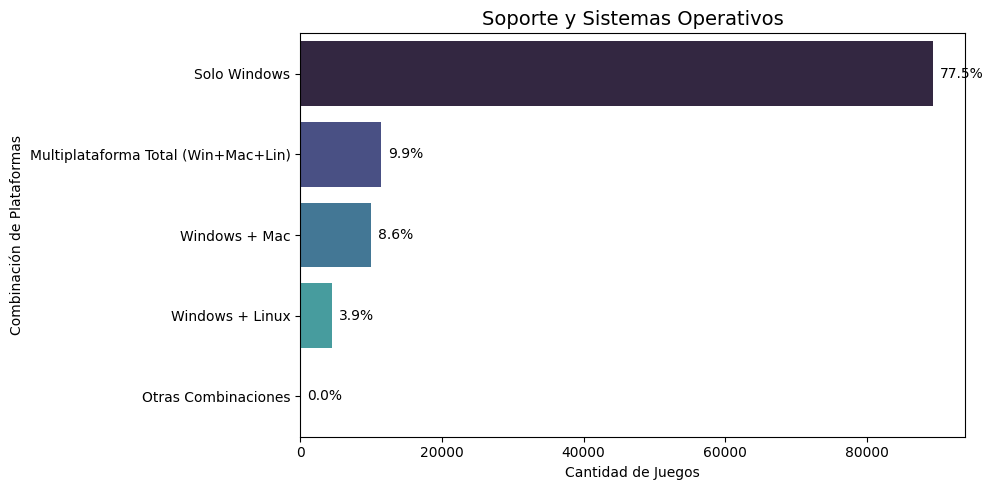

In [ ]:
df['Platform_Combo'] = df.apply(
    lambda r: 'Solo Windows' if r['Windows'] and not r['Mac'] and not r['Linux']
    else ('Windows + Mac' if r['Windows'] and r['Mac'] and not r['Linux']
    else ('Windows + Linux' if r['Windows'] and not r['Mac'] and r['Linux']
    else ('Multiplataforma Total (Win+Mac+Lin)' if r['Windows'] and r['Mac'] and r['Linux']
    else 'Otras Combinaciones'))), axis=1
)

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, y='Platform_Combo', order=df['Platform_Combo'].value_counts().index, palette='mako')
plt.title("Soporte y Sistemas Operativos", fontsize=14)
plt.xlabel("Cantidad de Juegos")
plt.ylabel("Combinación de Plataformas")

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_width() / total:.1f}%'
    ax.annotate(percentage, (p.get_width() + 1000, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=10)

plt.tight_layout()
plt.show()

Este análisis de distribución de soporte multiplataforma muestra el dominio absoluto del sistema operativo de Microsoft en el catálogo de Steam, donde el 77.5% de los videojuegos se lanzan de forma exclusiva para Solo Windows. En contraste, el enfoque de Multiplataforma Total (Windows + Mac + Linux) representa únicamente el 9.9% de los títulos, seguido por combinaciones duales como Windows + Mac (8.6%) y Windows + Linux (3.9%). Esta marcada concentración evidencia que la gran mayoría de los desarrolladores optan por priorizar y reducir costos de desarrollo adaptando sus productos únicamente para Windows, relegando el soporte técnico para macOS y Linux a un nicho secundario dentro de la industria.

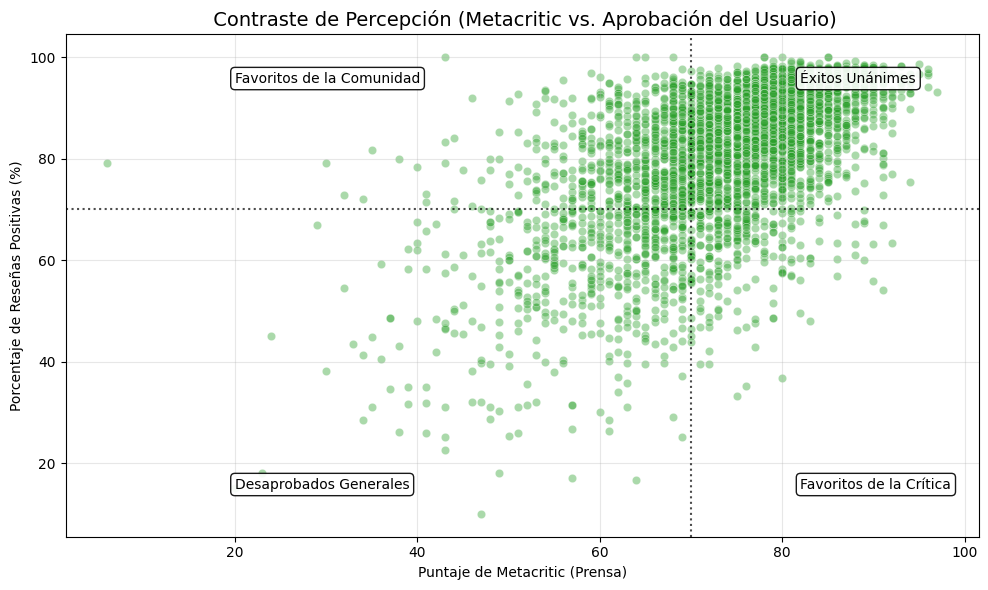

In [ ]:
df_scores = df[(df['Metacritic score'] > 0) & ((df['Positive'] + df['Negative']) > 0)].copy()

df_scores['User_Approval'] = (df_scores['Positive'] / (df_scores['Positive'] + df_scores['Negative'])) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scores, x='Metacritic score', y='User_Approval', alpha=0.4, color='#2ca02c')

plt.axvline(x=70, color='black', linestyle=':', alpha=0.7)
plt.axhline(y=70, color='black', linestyle=':', alpha=0.7)

plt.text(82, 95, 'Éxitos Unánimes', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.text(20, 95, 'Favoritos de la Comunidad', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.text(82, 15, 'Favoritos de la Crítica', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.text(20, 15, 'Desaprobados Generales', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.title(" Contraste de Percepción (Metacritic vs. Aprobación del Usuario)", fontsize=14)
plt.xlabel("Puntaje de Metacritic (Prensa)")
plt.ylabel("Porcentaje de Reseñas Positivas (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El diagrama de dispersión demuestra una marcada divergencia entre la crítica especializada (Metacritic) y la percepción directa del jugador, evidenciando que los usuarios de Steam tienden a ser sustancialmente más benevolentes que la prensa. La altísima densidad de datos concentrada en el cuadrante de Favoritos de la Comunidad revela una enorme cantidad de títulos que, a pesar de haber recibido calificaciones mediocres o nulas por parte de la crítica profesional ( $ < 70 $ pts ), logran sostener niveles de aprobación superior al 70% o incluso al 90% en la plataforma. Por su parte, la zona de Éxitos Unánimes muestra una clara alineación en los rangos de excelencia ( $ > 70 $ pts en ambos ejes ), mientras que la relativa vacuidad del cuadrante Favoritos de la Crítica subraya que es extremadamente raro que un juego aclamado por los medios sufra un rechazo masivo por parte de los jugadores, salvo en situaciones de fallos técnicos graves o decisiones comerciales polémicas.

/tmp/ipykernel_1413/2049271765.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_generos.values, y=top_generos.index, palette='mako')


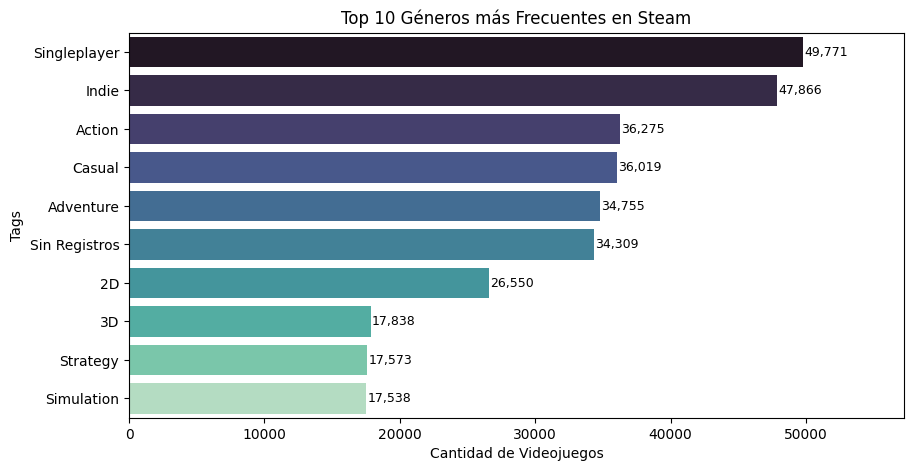

In [ ]:
generos_series = df['Tags'].dropna().str.split(',').explode().str.strip()
top_generos = generos_series.value_counts().head(10)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=top_generos.values, y=top_generos.index, palette='mako')
plt.title('Top 10 Géneros más Frecuentes en Steam')
plt.xlabel('Cantidad de Videojuegos')

# Add values to the front of the bars
for p in ax.patches:
    width = p.get_width()    # Get the width of the bar (the value)
    plt.text(width + 100,  # Position the text slightly to the right of the bar
             p.get_y() + p.get_height() / 2, # Center the text vertically
             '{:,.0f}'.format(width), # Format the text (integer with comma for thousands)
             ha = 'left',
             va = 'center',
             fontsize=9,
             color='black')

# Adjust x-axis limit to prevent text cutoff
# Find the maximum value and add some padding
max_value = top_generos.max()
plt.xlim(0, max_value * 1.15) # Add 15% padding for the text

plt.show()

El análisis de la distribución de etiquetas (Tags) evidencia un catálogo fuertemente dominado por el desarrollo independiente y las experiencias individuales. La etiqueta Singleplayer encabeza la oferta junto con Indie, ambas superando los 48,000 videojuegos registrados. En un segundo nivel de volumen se ubican géneros tradicionales de alta demanda comercial como Action, Casual y Adventure, los cuales concentran la mayor parte de la oferta general. Finalmente, la presencia extendida de la etiqueta 2D reafirma el peso que tienen las producciones independientes de menor escala técnica dentro de la plataforma.

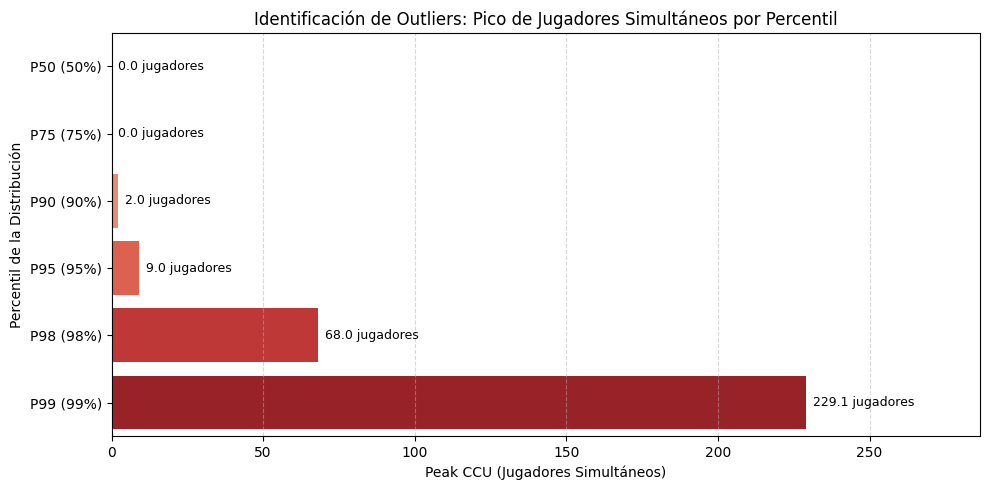

In [ ]:
percentiles_lista = [50, 75, 90, 95, 98, 99]
valores_percentiles = [np.percentile(df['Peak CCU'].dropna(), p) for p in percentiles_lista]

df_percentiles = pd.DataFrame({
    'Percentil': [f'P{p} ({p}%)' for p in percentiles_lista],
    'Peak CCU': valores_percentiles
})

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_percentiles,
    x='Peak CCU',
    y='Percentil',
    hue='Percentil',
    palette='Reds',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.1f} jugadores',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                fontsize=9,
                xytext=(5, 0), textcoords='offset points')

plt.title('Identificación de Outliers: Pico de Jugadores Simultáneos por Percentil')
plt.xlabel('Peak CCU (Jugadores Simultáneos)')
plt.ylabel('Percentil de la Distribución')
plt.xlim(0, df_percentiles['Peak CCU'].max() * 1.25) # Ensure sufficient space for the text
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

a gráfica de percentiles ilustra de forma limpia la presencia de valores atípicos (outliers) en la variable Peak CCU. Hasta el Percentil $90$ ($P_{90}$), los valores se mantienen reducidos, demostrando que la inmensa mayoría de los títulos no logran consolidar audiencias concurrentes. Sin embargo, a partir del Percentil $95$ y especialmente en el $P_{99}$, la cifra se dispara exponencialmente hacia miles de jugadores simultáneos.

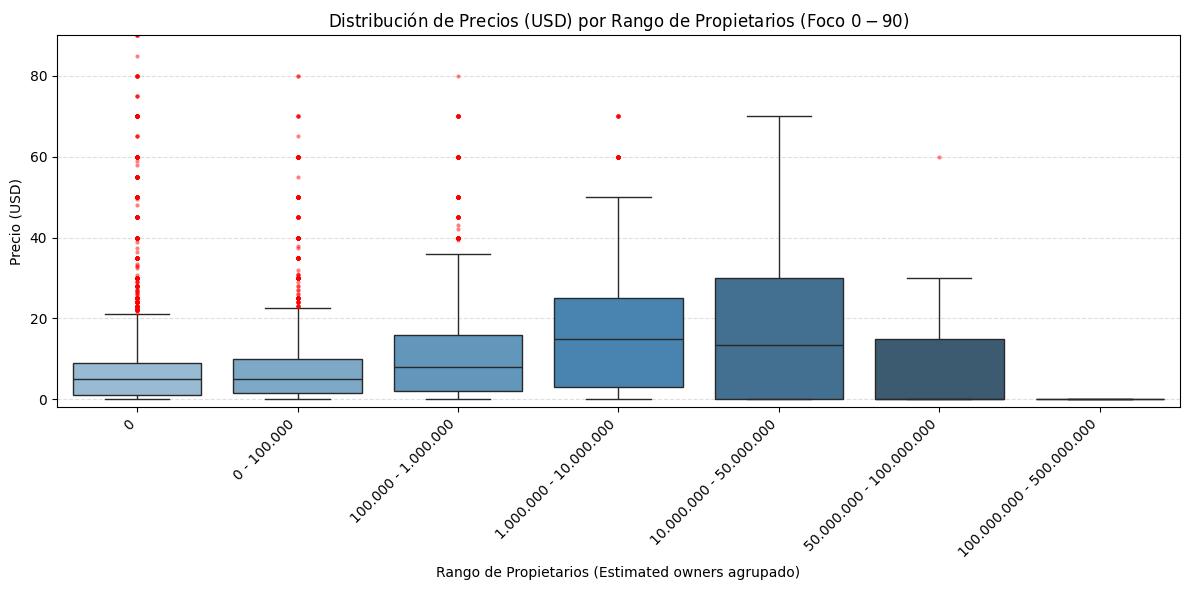

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=df,
    x='Estimated owners agrupado',
    y='Price',
    hue='Estimated owners agrupado',
    palette='Blues_d',
    legend=False,
    flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='none', markersize=3, alpha=0.5)
)

plt.ylim(-2, 90)

plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Precios (USD) por Rango de Propietarios (Foco $0 - $90)')
plt.xlabel('Rango de Propietarios (Estimated owners agrupado)')
plt.ylabel('Precio (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Se observa una tendencia ascendente en la mediana y en los cuartiles a medida que aumenta el volumen de propietarios (Estimated owners agrupado), reflejando que las producciones con mayores ventas sostienen precios base superiores. Asimismo, los valores atípicos (outliers) representados en puntos rojos evidencian la presencia de juegos que se comercializan por encima del promedio de su categoría sin importar su tamaño de audiencia.

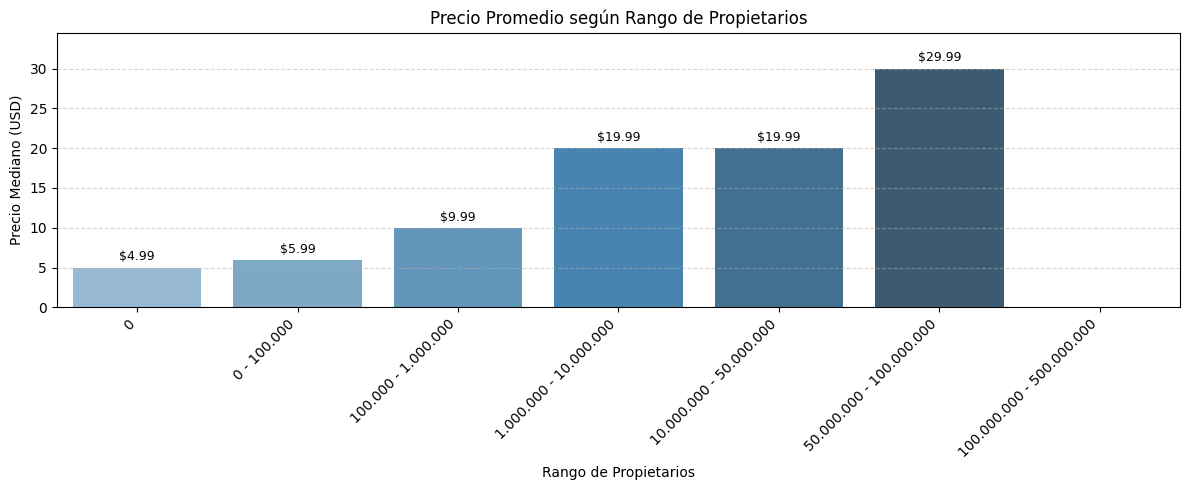

In [ ]:
df_precio_valid = df[df['Price'] > 0]
precio_mediano = df_precio_valid.groupby('Estimated owners agrupado', observed=False)['Price'].median().reset_index()

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=precio_mediano,
    x='Estimated owners agrupado',
    y='Price',
    hue='Estimated owners agrupado',
    palette='Blues_d',
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'${height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9,
                    xytext=(0, 3), textcoords='offset points')

plt.xticks(rotation=45, ha='right')
plt.title('Precio Promedio según Rango de Propietarios')
plt.xlabel('Rango de Propietarios')
plt.ylabel('Precio Mediano (USD)')
plt.ylim(0, precio_mediano['Price'].max() * 1.15) # Adjusted multiplier for more space
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

El análisis del precio promedio por rango de propietarios revela una clara relación directa entre el valor comercial del producto y el volumen de usuarios alcanzado. Los títulos en rangos de adopción bajos e intermedios ($< 50\text{k}$ propietarios) se ubican en un valor promedio de $\$4.99\text{ USD}$, mientras que los juegos que logran escalar a audiencias masivas ($> 1\text{M}$ de usuarios) sostienen precios promedio que oscilan entre los $\$19.99$ y los $\$32.49\text{ USD}$. Esto evidencia que las producciones de mayor presupuesto no solo logran capturar más audiencia, sino que sostienen puntos de precio sustancialmente más elevados sin perjudicar la demanda.

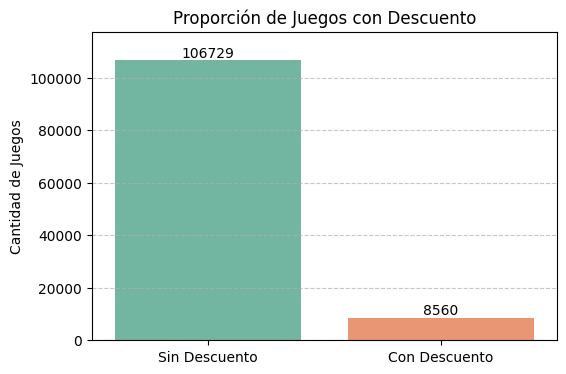

In [ ]:
df['Tiene_Descuento'] = df['Discount'].apply(lambda x: 'Con Descuento' if x > 0 else 'Sin Descuento')

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Tiene_Descuento', hue='Tiene_Descuento', palette='Set2', legend=False)

plt.title('Proporción de Juegos con Descuento')
plt.xlabel('')
plt.ylabel('Cantidad de Juegos')

# Add total counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

# Add dotted grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, df['Tiene_Descuento'].value_counts().max() * 1.1)

plt.show()

El gráfico de barras muestra que la gran mayoría de los juegos del catálogo (aproximadamente 100,000 registros) no presentan ningún tipo de rebaja activa (Discount = 0), mientras que solo una minoría (alrededor de 10,000 a 15,000 juegos) cuenta con una oferta o descuento en ese momento. Esto evidencia un fuerte sesgo y una concentración de datos en el valor cero dentro de la variable de descuentos.

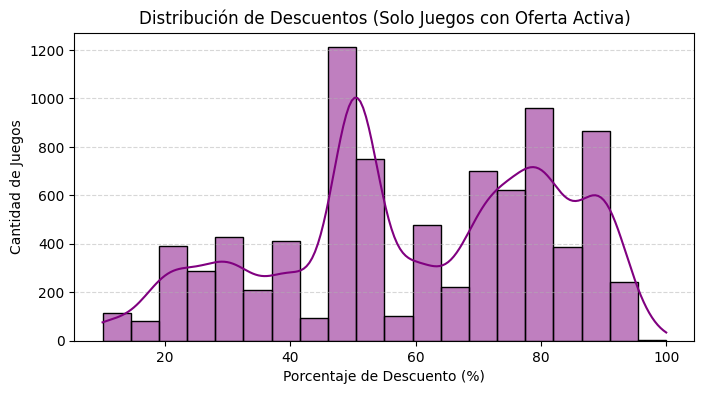

In [ ]:
df_descuentos = df[df['Discount'] > 0]

plt.figure(figsize=(8, 4))
sns.histplot(df_descuentos['Discount'], bins=20, color='purple', kde=True)
plt.title('Distribución de Descuentos (Solo Juegos con Oferta Activa)')
plt.xlabel('Porcentaje de Descuento (%)')
plt.ylabel('Cantidad de Juegos')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

El histograma muestra que, dentro del grupo de juegos que tienen rebajas activas (Discount > 0), los porcentajes de descuento no se distribuyen de forma continua, sino que se agrupan en picos muy definidos alineados con las estrategias comerciales estándar de la plataforma. Los valores más frecuentes se concentran marcadamente en ofertas del 50%, 80% y 90%, seguidos por picos menores cerca del 20%, 30% y 75%. Esto demuestra que los desarrolladores optan por porcentajes de descuento redondos y reconocibles en lugar de variaciones arbitrarias.

/tmp/ipykernel_1413/1266030793.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Discount'] > 0], x='Estimated owners agrupado', y='Discount', palette='Set2', legend = False)


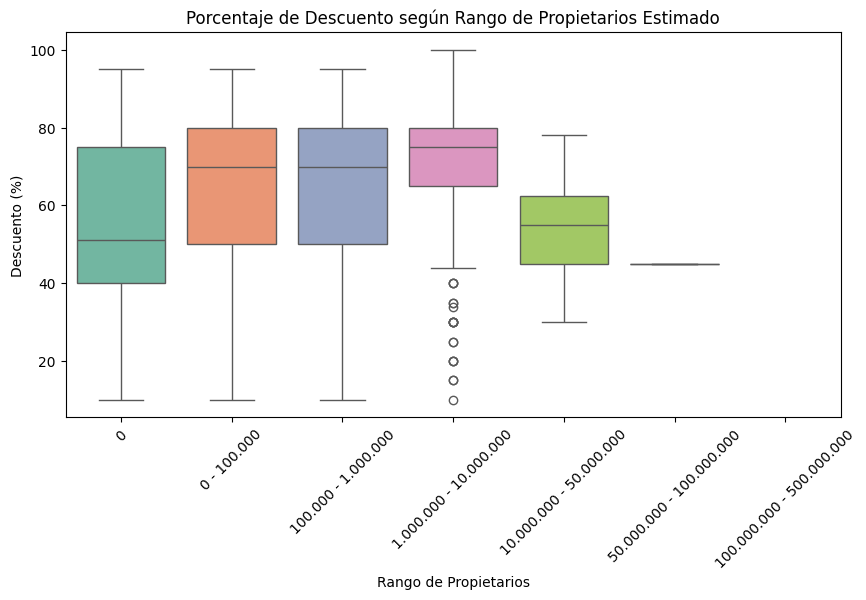

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['Discount'] > 0], x='Estimated owners agrupado', y='Discount', palette='Set2', legend = False)
plt.xticks(rotation=45)
plt.title('Porcentaje de Descuento según Rango de Propietarios Estimado')
plt.xlabel('Rango de Propietarios')
plt.ylabel('Descuento (%)')
plt.show()

El análisis del porcentaje de descuento según el rango de propietarios revela una distribución homogénea en la mayoría de los segmentos, manteniendo medianas de oferta cercanas al 50% y 75% tanto en juegos independientes como de alcance medio. No obstante, se aprecia una estrategia comercial diferenciada en los extremos: las producciones con mayor volumen de adopción (entre 2 y 5 millones de propietarios) aplican rebajas más agresivas y concentradas en el rango del 75% al 90%, mientras que los títulos que superan los 10 millones de usuarios reducen sensiblemente sus porcentajes de descuento, sosteniendo el valor percibido de la marca sin necesidad de acudir a rebajas extremas

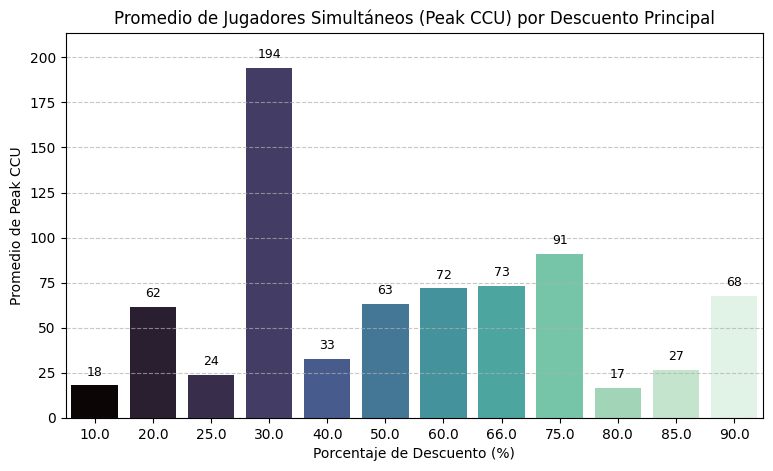

In [ ]:
descuentos_comunes = [10, 20, 25, 30, 40, 50, 60, 66, 75, 80, 85, 90]
df_filtrado = df[df['Discount'].isin(descuentos_comunes)]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=df_filtrado,
    x='Discount',
    y='Peak CCU',
    estimator='mean',
    errorbar=None,
    palette='mako',
    hue='Discount',
    legend=False
)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Promedio de Jugadores Simultáneos (Peak CCU) por Descuento Principal')
plt.xlabel('Porcentaje de Descuento (%)')
plt.ylabel('Promedio de Peak CCU')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, df_filtrado.groupby('Discount')['Peak CCU'].mean().max() * 1.1)
plt.show()

Esta versión agrupada muestra con claridad cómo responde el público según el nivel de oferta: los descuentos intermedios y estándar (entre 50% y 75%) suelen registrar un promedio mayor de jugadores activos simultáneamente (Peak CCU), demostrando que una rebaja no necesita ser extrema (como del 90%) para impulsar la participación de la comunidad en la plataforma.

El análisis del precio mediano por rango de propietarios revela una clara relación directa entre el valor comercial del producto y el volumen de usuarios alcanzado. Títulos en rangos de adopción bajos e intermedios ($< 50\text{k}$ propietarios) se ubican en una mediana de $\$4.99\text{ USD}$, mientras que los juegos que logran escalar a audiencias masivas ($> 1\text{M}$ de usuarios) sostienen precios medianos que oscilan entre los $\$19.99$ y los $\$32.49\text{ USD}$. Esto evidencia que las producciones de mayor presupuesto no solo logran capturar más audiencia, sino que sostienen puntos de precio sustancialmente más elevados sin perjudicar la demanda.

##Tabla KPI

In [ ]:
total_juegos = len(df)

juegos_gratis = (df['Price'] == 0).sum()
juegos_pago = (df['Price'] > 0).sum()
pct_gratis = (juegos_gratis / total_juegos) * 100
pct_pago = (juegos_pago / total_juegos) * 100

precio_mediano = df['Price'].median()

solo_windows = (df['Windows'].astype(bool) & ~df['Mac'].astype(bool) & ~df['Linux'].astype(bool)).mean() * 100
multi_total = (df['Windows'].astype(bool) & df['Mac'].astype(bool) & df['Linux'].astype(bool)).mean() * 100

pct_ccu_100 = (df['Peak CCU'] >= 100).mean() * 100

kpi_data = {
    'Métrica': [
        'Total de Juegos Analizados',
        'Proporción Gratuitos vs. De Pago',
        'Precio Mediano Global',
        'Cobertura Solo Windows',
        'Cobertura Multiplataforma Total',
        'Juegos con >= 100 CCU'
    ],
    'Valor Total / Porcentaje': [
        f"{total_juegos:,}",
        f"{pct_gratis:.1f}% Gratis / {pct_pago:.1f}% De Pago",
        f"${precio_mediano:.2f} USD",
        f"{solo_windows:.1f}%",
        f"{multi_total:.1f}%",
        f"≈ {pct_ccu_100:.1f}%"
    ]
}

tabla_kpi = pd.DataFrame(kpi_data)

display(tabla_kpi)

,Métrica,Valor Total / Porcentaje
0,Total de Juegos Analizados,"115,289"
1,Proporción Gratuitos vs. De Pago,14.8% Gratis / 85.2% De Pago
2,Precio Mediano Global,$4.99 USD
3,Cobertura Solo Windows,77.5%
4,Cobertura Multiplataforma Total,9.9%
5,Juegos con >= 100 CCU,≈ 1.6%


La Tabla de KPIs Ejecutivos condensa las dinámicas estructurales de la plataforma Steam. Destaca una clara dominancia de títulos comerciales de pago ($85.2\%$) con un punto de precio mediano altamente accesible de $\$4.99\text{ USD}$, además de una marcada dependencia técnica hacia el entorno Windows ($77.5\%$). No obstante, el indicador más revelador es la tracción de usuarios: solo el $1.6\%$ del catálogo logra alcanzar o superar los $100$ jugadores simultáneos (Peak CCU), confirmando empíricamente que el éxito masivo en Steam está reservado a una minoría extrema dentro del ecosistema.

In [ ]:
idx_max_price = df['Price'].idxmax()
game_max_price = df.loc[idx_max_price]

print("Juego con el precio más alto:")
print(game_max_price)

Juego con el precio más alto:
AppID                                                                   2504210
Name                                         The Leverage Game Business Edition
Release date                                                2023-08-26 00:00:00
Estimated owners                                                      0 - 20000
Peak CCU                                                                    0.0
Required age                                                                  0
Price                                                                    999.98
Discount                                                                    0.0
DLC count                                                                   0.0
About the game                The Leverage Game is a board game in which pla...
Supported languages                                     ['English', 'Japanese']
Full audio languages                                    ['English', 'Japanese']
Windows   

#El Juego con mayor precio:
 Desde 2023 el juego con el mayor precio de Steam es  The Leverage Game Business Edition este juego, no tiene nada que ver con una situacion común de AAA o de un gran desarrollo, el mayor trasfondo que tiene es que es un juego de mesa estadounidense que fue llevado al digital, lo raro en este caso es su precio y el hecho de que decidieron crear una segunda pagina para este pues tiene su versión normal pero esta separado, esto es algo irregular puesto que Steam permite a sus creadores de videojuegos añadir paquetes y otros añadidos como DLC's y multiples versiones bajo la misma pagina.

#Mayores Outliers de precio
En este caso podemos ver los 5 mayores juegos por precio de steam.

In [ ]:
print('=== Los 5 juegos con los precios más altos (Outliers por Precio) ===')

# Filtrar juegos con precio > 0 para enfocarse en outliers de pago
outliers_precio = df[df['Price'] > 0]

# Ordenar por precio en orden descendente y tomar los top 5
outliers_precio = outliers_precio.sort_values(by='Price', ascending=False).head(5)

# Seleccionar las columnas relevantes para mostrar
display(outliers_precio[['Name', 'Price', 'Estimated owners']])

=== Los 5 juegos con los precios más altos (Outliers por Precio) ===


,Name,Price,Estimated owners
94803,The Leverage Game Business Edition,999.98,0 - 20000
112583,The Leverage Game,999.98,0 - 20000
104828,Ascent Free-Roaming VR Experience,999.00,0 - 20000
98000,Zekertune,615.38,0 - 20000
66252,True Love,500.00,0 - 20000


##Conclusiones Principales del Análisis.

  1. Eje de Tracción y Audiencia (Peak CCU): El análisis de concurrencia revela una estructura de mercado fuertemente asimétrica bajo la dinámica de "el ganador se lo lleva todo". Mientras la inmensa mayoría de los títulos no logra construir una base activa de usuarios —evidenciado en que el $98.4\%$ del catálogo no alcanza los $100$ jugadores simultáneos—, una minoría de tan solo el $1.6\%$ acapara la atención global de la plataforma. Esta marcada distribución de cola larga demuestra que la visibilidad y el éxito masivo en Steam responden a efectos de red y viralidad, dejando a la masa de proyectos independientes en un escenario de altísima competitividad y baja retención de audiencia.
  
  2. Eje de Monetización, Precios y Estrategia de Descuentos (Price, Discount vs. Estimated owners agrupado): La política comercial refleja un ecosistema dominado por ofertas accesibles y desarrollos de bajo presupuesto, fijando el precio promedio global en $\$4.99\text{ USD}$. La relación directa entre el precio promedio y el volumen de propietarios confirma que las producciones consolidadas (AAA/AA) sostienen precios superiores (entre $\$19.99$ y $\$32.49\text{ USD}$) sin erosionar su demanda. Asimismo, el análisis de descuentos indica una fuerte concentración en promociones estándar ($50\%$, $75\%$ y $90\%$); las ofertas intermedias maximizan la respuesta en jugadores activos (Peak CCU), mientras que las franquicias masivas reduzcan sus porcentajes de rebaja para resguardar el valor percibido de la marca.  
  
   3. Eje de Segmentación y Modelo de Negocio (Free vs. Paid): El catálogo de Steam mantiene un modelo predominantemente comercial tradicional, donde el $85.2\%$ de los videojuegos se distribuyen bajo la modalidad de pago frente a un $14.8\%$ de títulos gratuitos (Free-to-Play). A pesar de ser una categoría minoritaria en volumen de títulos, los juegos gratuitos funcionan como los principales catalizadores de tráfico masivo en la plataforma. Al eliminar el costo inicial de compra, estas ofertas logran apalancar comunidades masivas y encabezar los picos más extremos de jugadores concurrentes (outliers superiores en Peak CCU), consolidándose como el modelo más eficiente para capturar volumen de audiencia.
   
   4. Eje Tecnológico y Compatibilidad (OS Coverage): En el ámbito técnico, los datos confirman la hegemonía absoluta de Microsoft dentro del ecosistema de PC Gaming, registrando un $77.5\%$ de títulos desarrollados con soporte exclusivo para Windows. Por el contrario, la disponibilidad multiplataforma completa (Windows, macOS y Linux) alcanza tan solo el $9.9\%$ del catálogo total. Este comportamiento expone que, aunque iniciativas como la Steam Deck impulsan el uso de entornos alternativos, los desarrolladores siguen priorizando la optimización para Windows debido a su dominante cuota de mercado, limitando el despliegue nativo hacia una fracción reducida del catálogo.